# Analisis Pengujian: Q-Learning vs Q-Learning Crisp vs Q-Learning Fuzzy vs HPA

Analisis komparatif hasil pengujian empat metode autoscaling.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

DATA_DIR = 'data/testing/60-episodes'

# One run each: pick 1 q, 1 qcrisp, 1 qfuzzy (from run folder '1') and 1 hpa
FILES = {
    'ql':     f'{DATA_DIR}/1/test_qlearning_20260807_143047.csv',
    'qcrisp': f'{DATA_DIR}/1/test_qlearningcrisp_20260807_142854.csv',
    'qfuzzy': f'{DATA_DIR}/1/test_qlearningfuzzy_20260807_142708.csv',
    'hpa':    f'{DATA_DIR}/hpa/metrics_20260807_162124.csv',
}

# Method order, colors and labels
METHODS = ['ql', 'qcrisp', 'qfuzzy', 'hpa']
COLORS = {'ql': '#26A69A', 'qcrisp': '#EC407A', 'qfuzzy': '#5C6BC0', 'hpa': '#FF7043'}
LABELS = {'ql': 'Q-Learning', 'qcrisp': 'Q-Learning Crisp', 'qfuzzy': 'Q-Learning Fuzzy', 'hpa': 'HPA'}

# Load data
dfs = {k: pd.read_csv(path, parse_dates=['timestamp']) for k, path in FILES.items()}

print('Raw row counts:')
for k in METHODS:
    print(f'  {LABELS[k]:<20}: {len(dfs[k])} rows')

# Use elapsed time (seconds from start) for x-axis alignment
for k in METHODS:
    dfs[k]['elapsed_s'] = (dfs[k]['timestamp'] - dfs[k]['timestamp'].iloc[0]).dt.total_seconds()

# Trim on a COMMON TIME HORIZON, not on a common row count.
#
# The collector samples every ~COLLECT_INTERVAL seconds, but the effective cadence
# differs per run (RL runs ~16.2 s/row, HPA ~17.3 s/row, plus occasional gaps), so
# an equal number of rows does NOT mean equal wall-clock coverage. Cutting every run
# to the smallest row count (92) would end the RL runs at ~1500 s while HPA keeps its
# full ~1947 s - the RL runs would lose the k6 ramp-down stage, which is exactly their
# best-latency period, inflating their SLO violation rate by 6-9 pp. Aligning on
# elapsed time keeps every method on the same slice of the load profile.
HORIZON_S = min(dfs[k]['elapsed_s'].max() for k in METHODS)
for k in METHODS:
    dfs[k] = dfs[k].loc[dfs[k]['elapsed_s'] <= HORIZON_S].reset_index(drop=True)
print(f'\nTrimmed to a common horizon of {HORIZON_S:.0f}s ({HORIZON_S / 60:.1f} min)')

print('\nAfter trimming:')
for k in METHODS:
    print(f'  {LABELS[k]:<20}: {len(dfs[k])} rows, {dfs[k]["elapsed_s"].iloc[-1]:.0f}s duration')

# Convenience list used by every plotting cell
datasets = [(k, dfs[k], LABELS[k]) for k in METHODS]

Raw row counts:
  Q-Learning          : 117 rows
  Q-Learning Crisp    : 124 rows
  Q-Learning Fuzzy    : 120 rows
  HPA                 : 92 rows

Trimmed to a common horizon of 1920s (32.0 min)

After trimming:
  Q-Learning          : 117 rows, 1920s duration
  Q-Learning Crisp    : 116 rows, 1905s duration
  Q-Learning Fuzzy    : 117 rows, 1914s duration
  HPA                 : 90 rows, 1915s duration


## Pola Beban Pengujian (k6 ramping-vus)

Profil beban yang dijalankan pada seluruh run pengujian, sesuai `SINGLE_CYCLE` pada
`agent-dipa/load-resource-intensive-ii/k6-train-patterns-loop.js`. Angka target berlaku
**per skenario**; dua skenario (`cpu_stress` dan `memory_stress`) berjalan bersamaan,
sehingga konkurensi total adalah dua kali nilai ini (puncak 150 VUs, sesuai `vus_max=150`
pada ringkasan k6 setiap run).

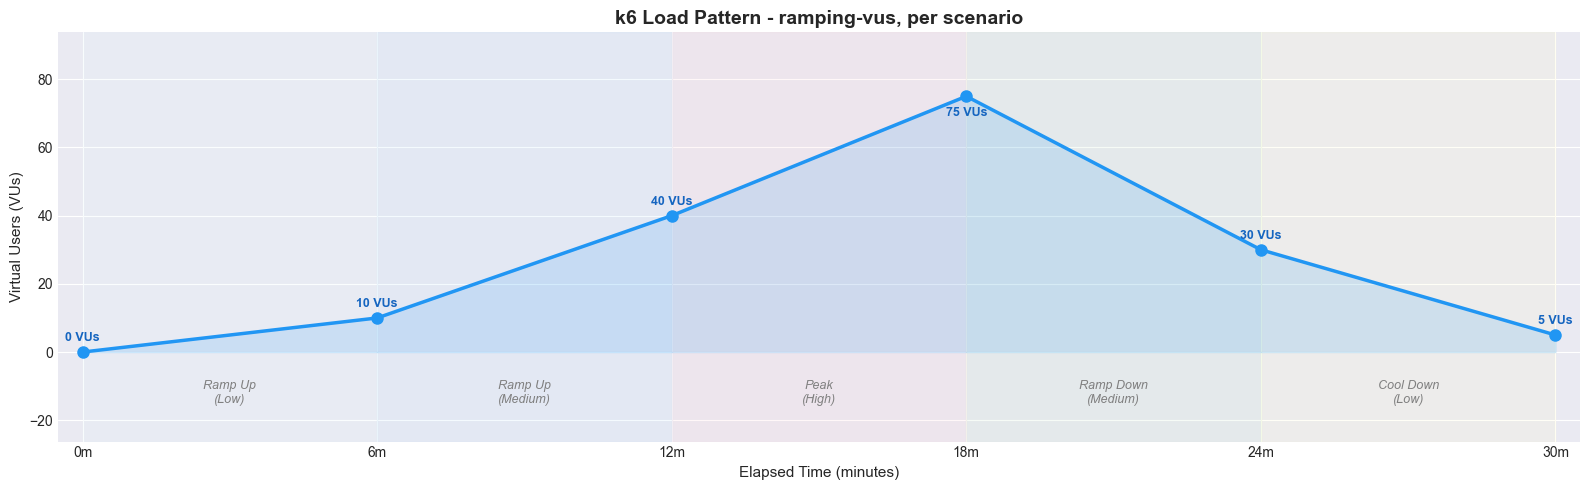

In [56]:
# k6 ramping-vus stages, PER SCENARIO. Single definition site: the cells further
# down (6.1.11 - 6.1.13) reuse k6_stages / k6_times_min / k6_vus from here.
#
# Source: SINGLE_CYCLE in agent-dipa/load-resource-intensive-ii/k6-train-patterns-loop.js
# Confirmed by the k6 end-of-test summaries in data/testing/60-episodes/*/image.png:
# every run reports vus_max = 150, and ramping-vus pre-allocates max(stage targets)
# per scenario, so 150 = 75 + 75 across the two concurrent scenarios.
k6_stages = [
    {"duration_min": 6, "target": 10},
    {"duration_min": 6, "target": 40},
    {"duration_min": 6, "target": 75},
    {"duration_min": 6, "target": 30},
    {"duration_min": 6, "target": 5},
]

# Build the VU time series (startVUs = 0)
k6_times_min = [0]
k6_vus = [0]
t = 0
for stage in k6_stages:
    t += stage["duration_min"]
    k6_times_min.append(t)
    k6_vus.append(stage["target"])

VU_MAX = max(k6_vus)

stage_colors = ['#E3F2FD', '#BBDEFB', '#FFCDD2', '#C8E6C9', '#FFF9C4']
stage_labels = ['Ramp Up\n(Low)', 'Ramp Up\n(Medium)', 'Peak\n(High)', 'Ramp Down\n(Medium)', 'Cool Down\n(Low)']

# --- Load pattern only ---
fig, ax = plt.subplots(figsize=(16, 5))

for i in range(len(k6_stages)):
    ax.axvspan(k6_times_min[i], k6_times_min[i + 1], alpha=0.15, color=stage_colors[i])

ax.plot(k6_times_min, k6_vus, marker='o', linewidth=2.5, color='#2196F3',
        markersize=8, zorder=3)
ax.fill_between(k6_times_min, k6_vus, alpha=0.15, color='#2196F3')

for t_val, v in zip(k6_times_min, k6_vus):
    offset_y = 8 if v != VU_MAX else -14
    ax.annotate(f'{v} VUs', (t_val, v), textcoords='offset points',
                xytext=(0, offset_y), ha='center', fontsize=9, fontweight='bold', color='#1565C0')

for i in range(len(k6_stages)):
    mid = (k6_times_min[i] + k6_times_min[i + 1]) / 2
    ax.text(mid, -0.20 * VU_MAX, stage_labels[i], ha='center', fontsize=9, style='italic', color='gray')

ax.set_xlabel('Elapsed Time (minutes)', fontsize=11)
ax.set_ylabel('Virtual Users (VUs)', fontsize=11)
ax.set_title('k6 Load Pattern - ramping-vus, per scenario', fontsize=14, fontweight='bold')
ax.set_xticks(k6_times_min)
ax.set_xticklabels([f'{tt}m' for tt in k6_times_min])
ax.set_xlim(-0.5, max(k6_times_min) + 0.5)
# Limits derived from the data so the peak and its annotation always fit.
ax.set_ylim(-0.35 * VU_MAX, VU_MAX * 1.25)

plt.tight_layout()
plt.show()


## 6.1.7 Hasil SLO Response Time Selama Pengujian

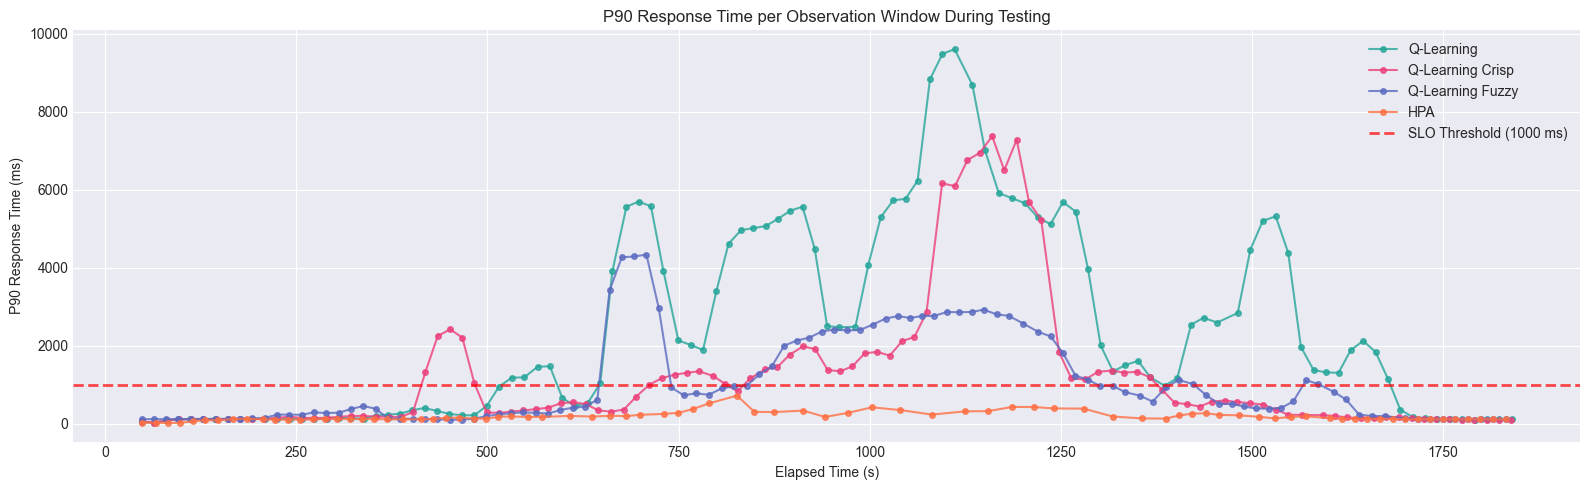

      P90 Response Time Statistics (ms, per observation window)       
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                  2424.7   1464.1     32.5   9606.8   2493.1
Q-Learning Crisp            1199.1    508.1     29.4   7372.5   1726.8
Q-Learning Fuzzy            1044.5    514.1    106.7   4340.4   1112.7
HPA                          192.7    141.0     26.2    725.6    119.0


In [57]:
SLO_THRESHOLD = 1000  # ms (= MAX_RESPONSE_TIME in agent-dipa/.env)

# What `response_time_ms` actually is:
# agent-dipa/utils/metrics.py::_get_response_time runs histogram_quantile(0.90, ...)
# once PER ENDPOINT (/cpu POST, /memory POST) and averages the two results. So each
# CSV row is the mean of the per-endpoint P90s over one observation window (~15 s
# apart, computed on a rate() window of METRICS_INTERVAL seconds) - not the P90 of a
# single request, and not the combined P90 across both endpoints. Everything below is
# therefore reported PER OBSERVATION WINDOW, never per request.

# --- Response Time Line Chart ---
fig, ax = plt.subplots(figsize=(16, 5))

for key, df, label in datasets:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    ax.plot(df.loc[mask, 'elapsed_s'], df.loc[mask, 'response_time_ms'],
            marker='o', markersize=4, linewidth=1.5, label=label, color=COLORS[key], alpha=0.8)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('P90 Response Time (ms)')
ax.set_title('P90 Response Time per Observation Window During Testing')
ax.legend()

plt.tight_layout()
plt.show()

# Response Time Statistics
print(f'{"P90 Response Time Statistics (ms, per observation window)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    valid = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
    if len(valid) > 0:
        print(f'{label:<25} {valid.mean():>8.1f} {valid.median():>8.1f} {valid.min():>8.1f} {valid.max():>8.1f} {valid.std():>8.1f}')
    else:
        print(f'{label:<25} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8}')

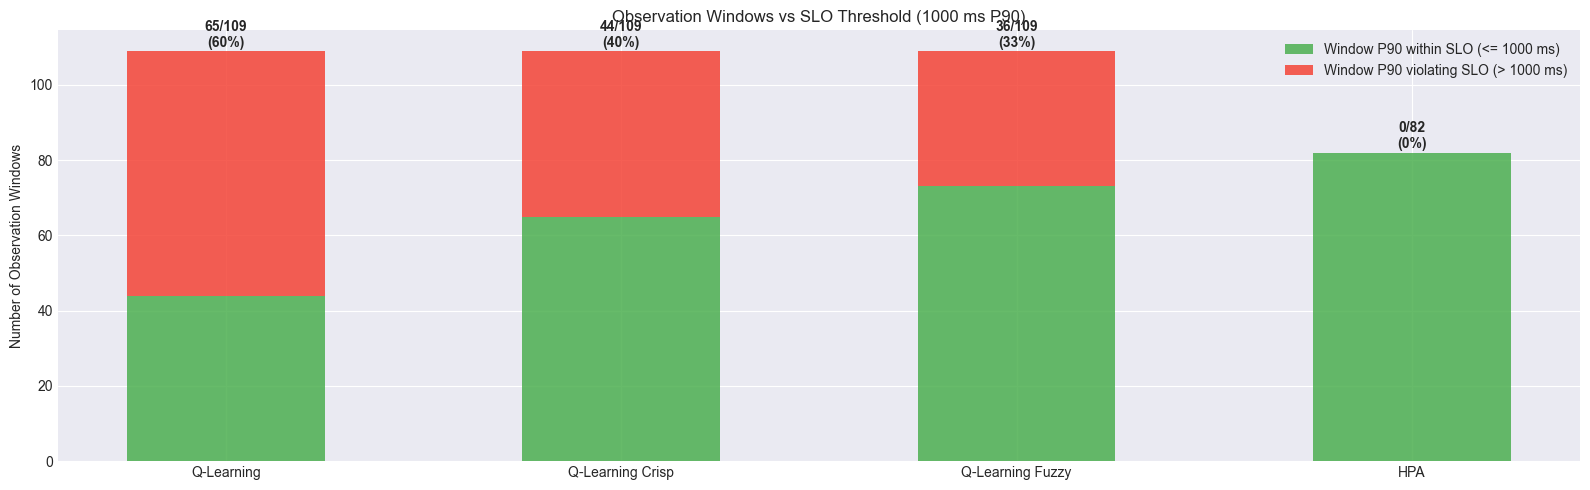


     SLO SUMMARY - SHARE OF OBSERVATION WINDOWS (not of requests)     
Method                     Windows   Within SLO   Violations  Violation %
----------------------------------------------------------------------
Q-Learning                     109           44           65        59.6%
Q-Learning Crisp               109           65           44        40.4%
Q-Learning Fuzzy               109           73           36        33.0%
HPA                             82           82            0         0.0%


In [58]:
# --- SLO Violation Count ---
#
# This measures the share of OBSERVATION WINDOWS whose P90 exceeded the threshold.
# It is NOT the share of individual requests slower than 1000 ms - that would need
# sum(rate(..._bucket{le="1"})) / sum(rate(..._count)), which the collector does not
# record. Windows with no traffic (response_time_ms = NaN, which lines up exactly
# with request_rate_rps == 0) are excluded, so the totals differ per method. Windows
# are also weighted equally regardless of how many requests they carried.
fig, ax = plt.subplots(figsize=(16, 5))

violations = {}
totals = {}
for key, df, label in datasets:
    valid = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    total = valid.sum()
    over_slo = (df.loc[valid, 'response_time_ms'] > SLO_THRESHOLD).sum()
    violations[label] = over_slo
    totals[label] = total

labels_list = list(violations.keys())
violation_counts = list(violations.values())
total_counts = [totals[l] for l in labels_list]
within_counts = [t - v for t, v in zip(total_counts, violation_counts)]

x = np.arange(len(labels_list))
width = 0.5

ax.bar(x, within_counts, width, label=f'Window P90 within SLO (<= {SLO_THRESHOLD} ms)', color='#4CAF50', alpha=0.85)
ax.bar(x, violation_counts, width, bottom=within_counts, label=f'Window P90 violating SLO (> {SLO_THRESHOLD} ms)', color='#F44336', alpha=0.85)

for i, (v, t) in enumerate(zip(violation_counts, total_counts)):
    pct = v / t * 100 if t > 0 else 0
    ax.text(i, t + 0.3, f'{v}/{t}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Number of Observation Windows')
ax.set_title(f'Observation Windows vs SLO Threshold ({SLO_THRESHOLD} ms P90)')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.legend()

plt.tight_layout()
plt.show()

# SLO Summary Table
print(f'\n{"=" * 70}')
print(f'{"SLO SUMMARY - SHARE OF OBSERVATION WINDOWS (not of requests)":^70}')
print(f'{"=" * 70}')
print(f'{"Method":<25} {"Windows":>8} {"Within SLO":>12} {"Violations":>12} {"Violation %":>12}')
print(f'{"-" * 70}')
for label in labels_list:
    t = totals[label]
    v = violations[label]
    w = t - v
    pct = v / t * 100 if t > 0 else 0
    print(f'{label:<25} {t:>8} {w:>12} {v:>12} {pct:>11.1f}%')

## 6.1.8 Hasil Utilisasi CPU dan Memori Selama Pengujian

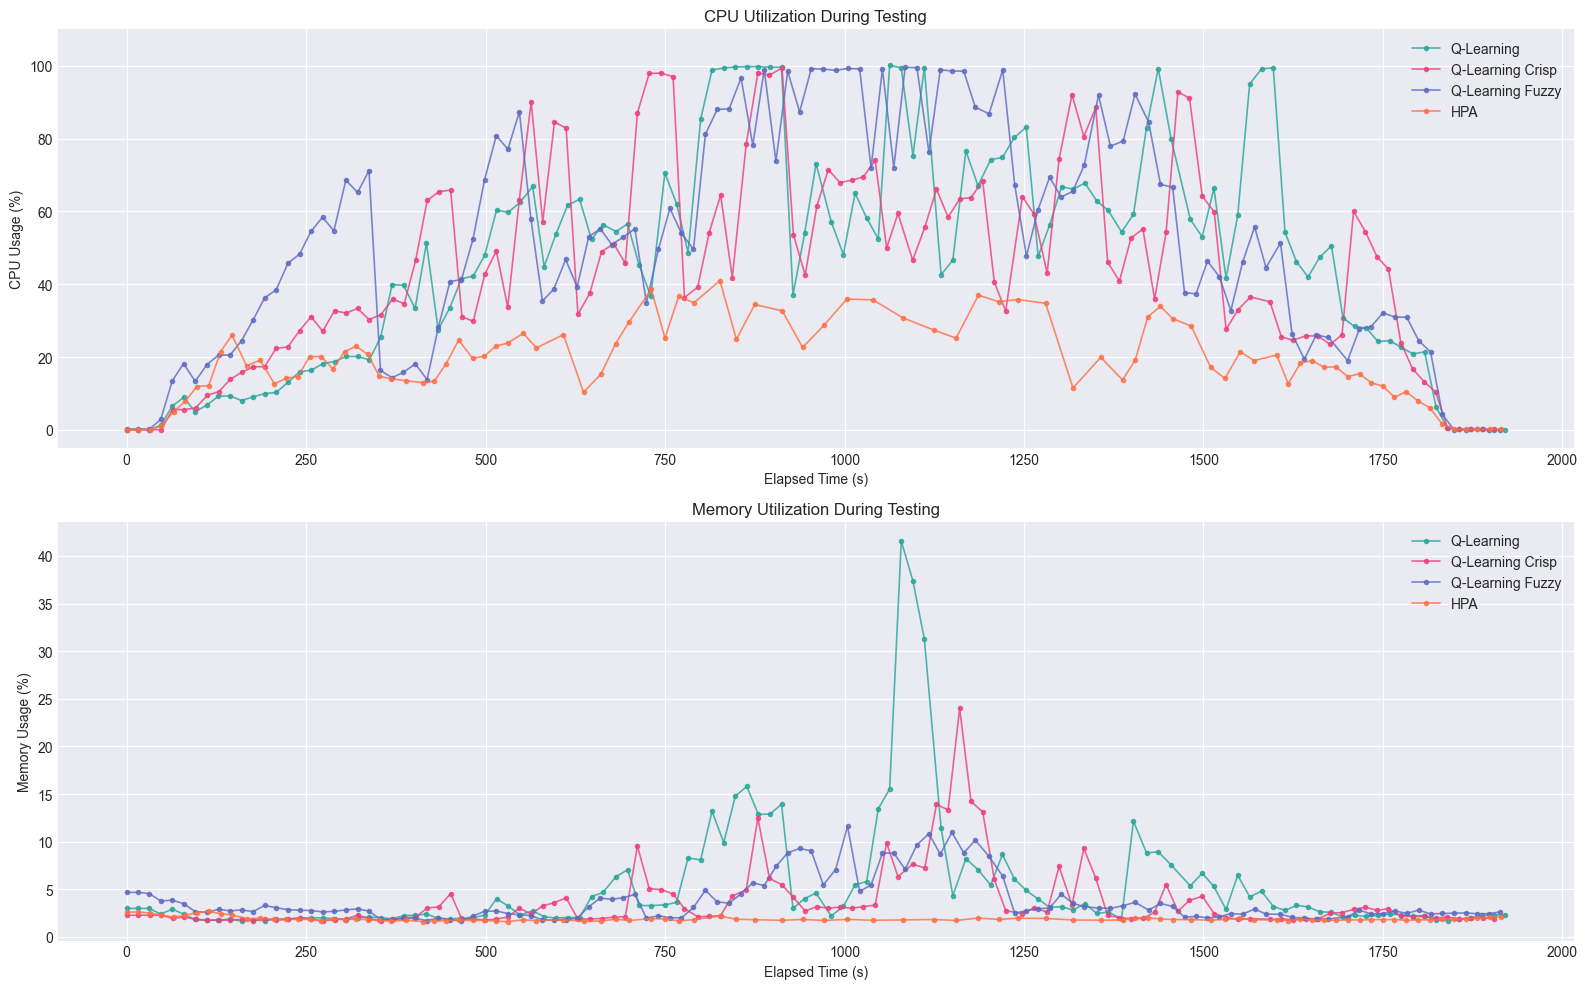


                   CPU & MEMORY UTILIZATION SUMMARY                   

                            CPU Usage (%)                             
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                   47.32    48.65    0.060   100.16    30.16
Q-Learning Crisp             45.14    42.89    0.050    99.39    27.04
Q-Learning Fuzzy             52.02    51.34    0.053    99.57    30.39
HPA                          19.02    19.09    0.068    41.01    10.57

                           Memory Usage (%)                           
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                    5.16     2.93    1.669    41.57     6.22
Q-L

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Top: CPU Usage ---
ax = axes[0]
for key, df, label in datasets:
    ax.plot(df['elapsed_s'], df['cpu_usage'], marker='o', markersize=3, linewidth=1.2,
            label=label, color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('CPU Usage (%)')
ax.set_title('CPU Utilization During Testing')
ax.set_ylim(-5, 110)
ax.legend()

# --- Bottom: Memory Usage ---
ax = axes[1]
for key, df, label in datasets:
    ax.plot(df['elapsed_s'], df['memory_usage'], marker='o', markersize=3, linewidth=1.2,
            label=label, color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Memory Usage (%)')
ax.set_title('Memory Utilization During Testing')
ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(f'\n{"=" * 70}')
print(f'{"CPU & MEMORY UTILIZATION SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'\n{"CPU Usage (%)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    cpu = df['cpu_usage']
    print(f'{label:<25} {cpu.mean():>8.2f} {cpu.median():>8.2f} {cpu.min():>8.3f} {cpu.max():>8.2f} {cpu.std():>8.2f}')

print(f'\n{"Memory Usage (%)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    mem = df['memory_usage']
    print(f'{label:<25} {mem.mean():>8.2f} {mem.median():>8.2f} {mem.min():>8.3f} {mem.max():>8.2f} {mem.std():>8.2f}')

## 6.1.9 Hasil Jumlah Replica Selama Pengujian

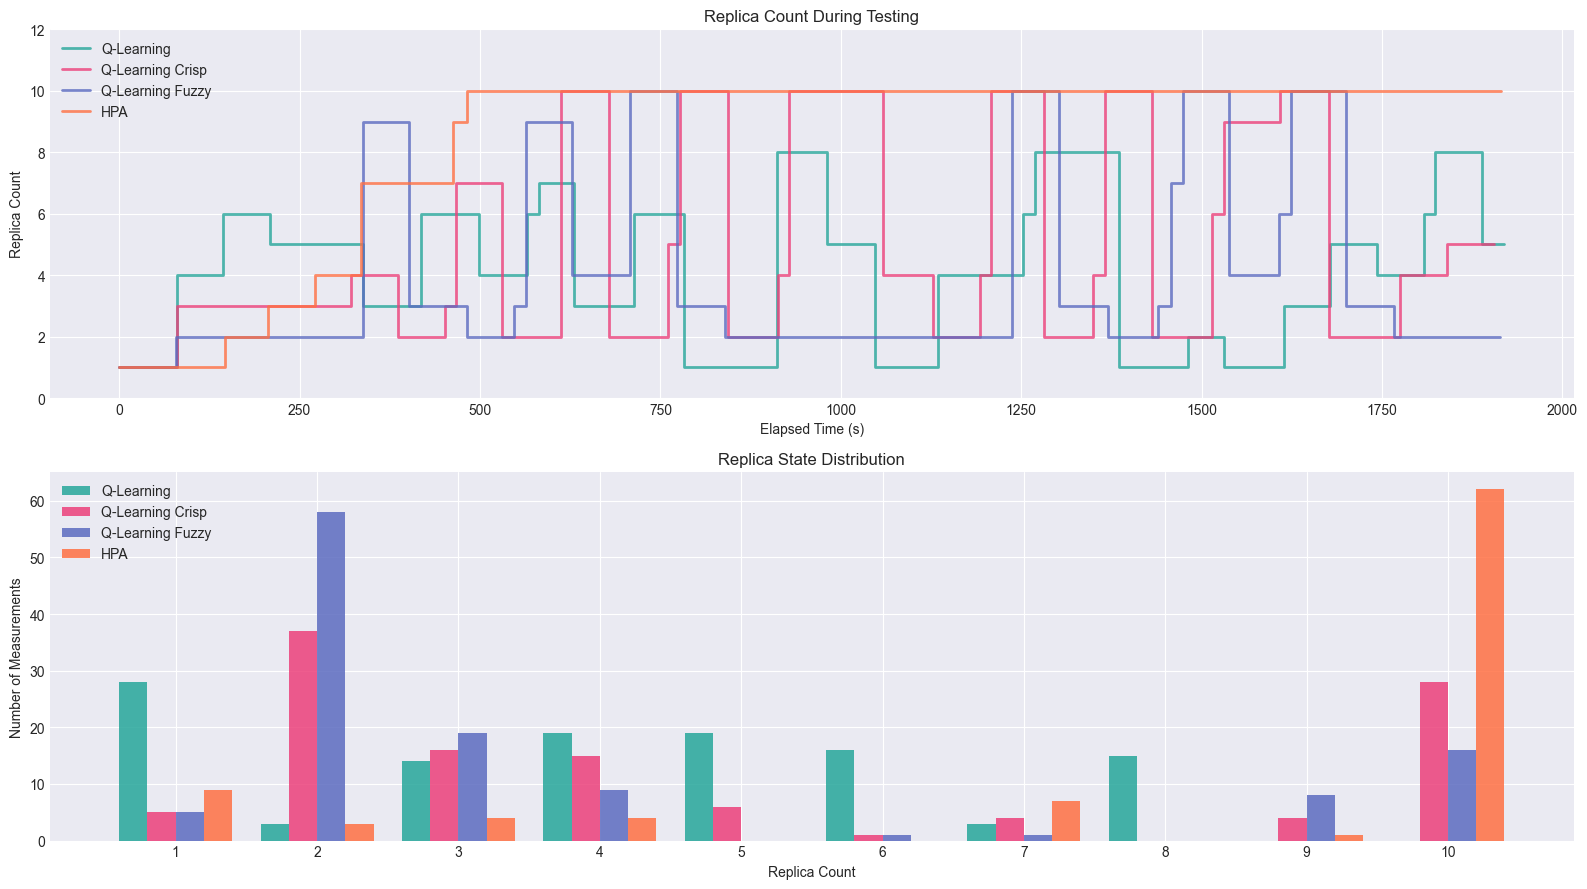


                        REPLICA COUNT SUMMARY                         
Method                        Mean    Min    Max   Mode  Changes
----------------------------------------------------------------------
Q-Learning                    4.14      1      8      1       26
Q-Learning Crisp              4.89      1     10      2       27
Q-Learning Fuzzy              3.92      1     10      2       21
HPA                           8.01      1     10     10        6


In [60]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# --- Top: Replica count over time ---
ax = axes[0]
for key, df, label in datasets:
    ax.step(df['elapsed_s'], df['replica_state'], where='post', linewidth=2,
            label=label, color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Replica Count')
ax.set_title('Replica Count During Testing')
ax.set_ylim(0, max(df['replica_state'].max() for _, df, _ in datasets) + 2)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend()

# --- Bottom: Replica distribution bar chart ---
ax = axes[1]
all_replicas = sorted(set().union(*[set(df['replica_state'].unique()) for _, df, _ in datasets]))
x = np.arange(len(all_replicas))
n = len(datasets)
width = 0.8 / n

for i, (key, df, label) in enumerate(datasets):
    counts = df['replica_state'].value_counts().sort_index()
    vals = [counts.get(r, 0) for r in all_replicas]
    ax.bar(x + (i - (n - 1) / 2) * width, vals, width, label=label, color=COLORS[key], alpha=0.85)

ax.set_xlabel('Replica Count')
ax.set_ylabel('Number of Measurements')
ax.set_title('Replica State Distribution')
ax.set_xticks(x)
ax.set_xticklabels(all_replicas)
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print(f'\n{"=" * 70}')
print(f'{"REPLICA COUNT SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Min":>6} {"Max":>6} {"Mode":>6} {"Changes":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    rep = df['replica_state']
    changes = (rep.diff().fillna(0) != 0).sum()
    print(f'{label:<25} {rep.mean():>8.2f} {rep.min():>6} {rep.max():>6} {rep.mode().iloc[0]:>6} {changes:>8}')

## 6.1.10 Analisis Efisiensi Sumber Daya: Overprovisioning vs Underprovisioning

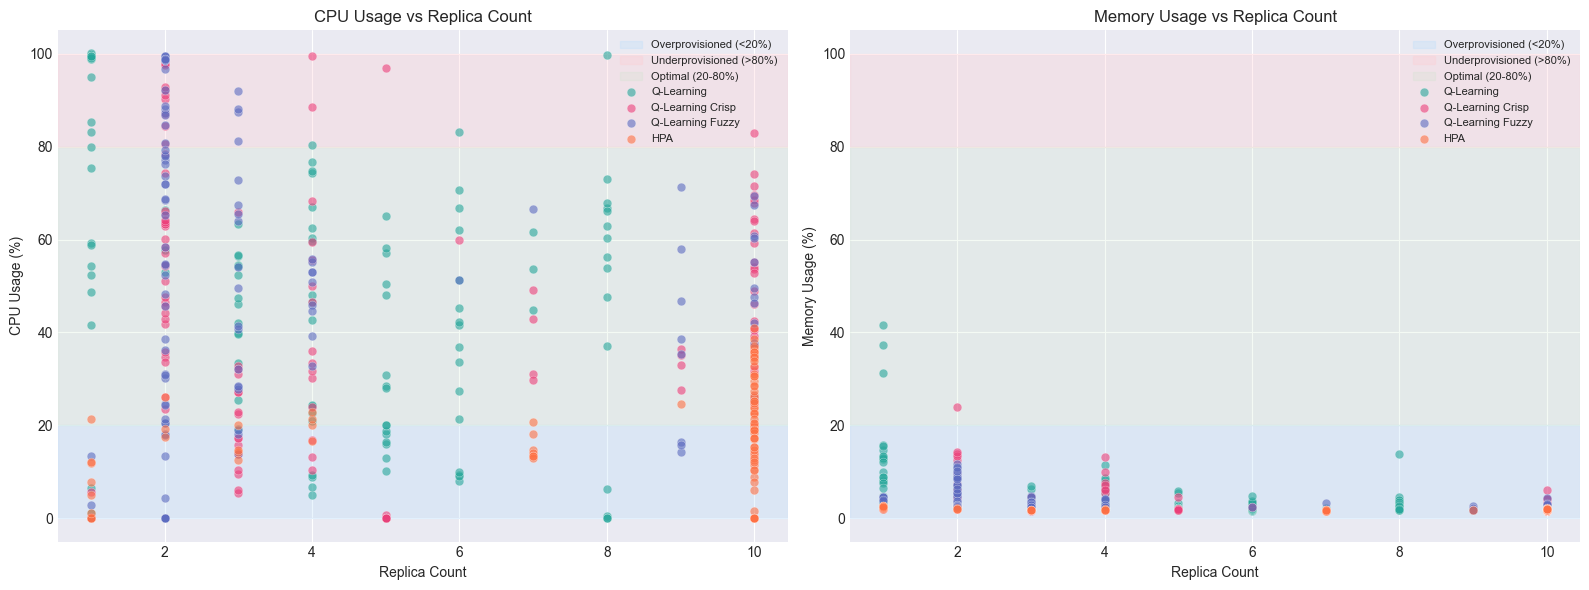

C:\Users\indra\AppData\Local\Temp\ipykernel_23492\1255988056.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)
C:\Users\indra\AppData\Local\Temp\ipykernel_23492\1255988056.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)


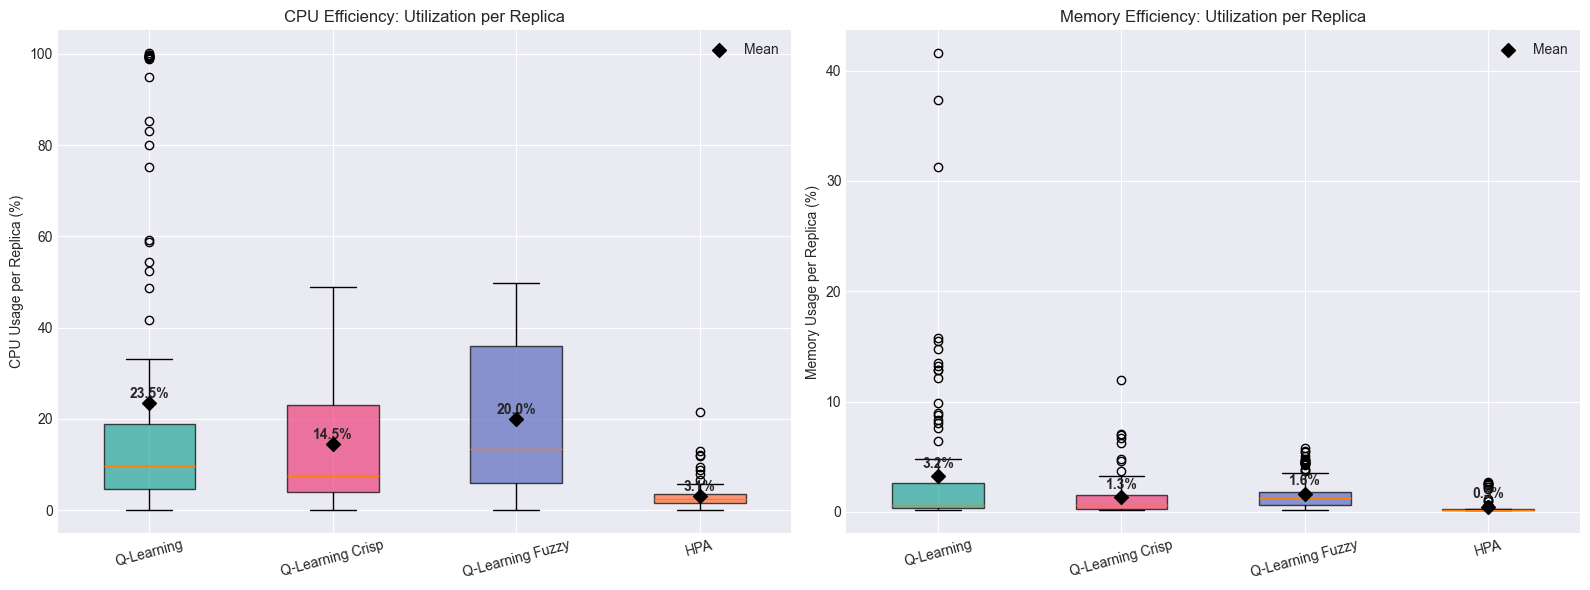

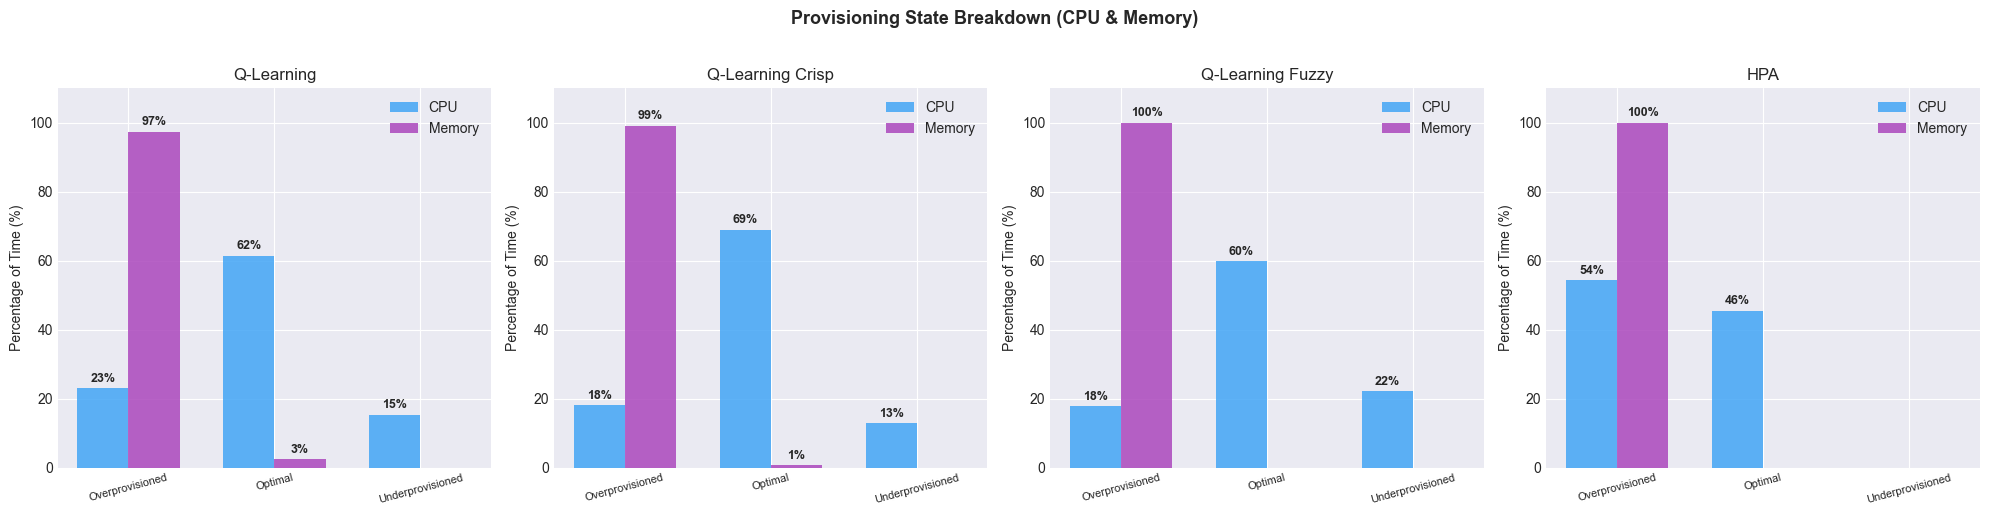


                          RESOURCE EFFICIENCY SUMMARY                           

Method                Avg Replica   Avg CPU   Avg MEM   CPU/Rep   MEM/Rep
--------------------------------------------------------------------------------
Q-Learning                   4.14    47.32%     5.16%    11.44%     1.25%
Q-Learning Crisp             4.89    45.14%     3.64%     9.24%     0.75%
Q-Learning Fuzzy             3.92    52.02%     3.78%    13.26%     0.96%
HPA                          8.01    19.02%     1.89%     2.37%     0.24%

                             Provisioning Breakdown                             
--------------------------------------------------------------------------------
Method                Over (CPU)   Opt (CPU)  Under (CPU)  Over (MEM)   Opt (MEM)  Under (MEM)
--------------------------------------------------------------------------------
Q-Learning                 23.1%       61.5%        15.4%       97.4%        2.6%         0.0%
Q-Learning Crisp           18.1%

In [61]:
# Overprovisioning/Underprovisioning thresholds
CPU_LOW, CPU_HIGH = 20, 80   # from .env MIN_CPU, MAX_CPU
MEM_LOW, MEM_HIGH = 20, 80   # from .env MIN_MEMORY, MAX_MEMORY

# --- 1) CPU & Memory vs Replica (scatter) with provisioning zones ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, label_y in zip(axes, ['cpu_usage', 'memory_usage'], ['CPU Usage (%)', 'Memory Usage (%)']):
    # Shaded zones
    ax.axhspan(0, CPU_LOW, color='#BBDEFB', alpha=0.3, label=f'Overprovisioned (<{CPU_LOW}%)')
    ax.axhspan(CPU_HIGH, 100, color='#FFCDD2', alpha=0.3, label=f'Underprovisioned (>{CPU_HIGH}%)')
    ax.axhspan(CPU_LOW, CPU_HIGH, color='#C8E6C9', alpha=0.2, label=f'Optimal ({CPU_LOW}-{CPU_HIGH}%)')

    for key, df, label in datasets:
        ax.scatter(df['replica_state'], df[metric], s=40, alpha=0.6,
                   color=COLORS[key], label=label, edgecolors='white', linewidth=0.3)

    ax.set_xlabel('Replica Count')
    ax.set_ylabel(label_y)
    ax.set_title(f'{label_y.split(" (")[0]} vs Replica Count')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# --- 2) Utilisasi per Replica (efisiensi) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(axes, ['cpu_usage', 'memory_usage'], ['CPU', 'Memory']):
    bp_data = [dfs[k][metric] / dfs[k]['replica_state'] for k in METHODS]
    bp_labels = [LABELS[k] for k in METHODS]
    bp_colors = [COLORS[k] for k in METHODS]

    bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], bp_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Mean markers
    means = [d.mean() for d in bp_data]
    ax.scatter(range(1, len(METHODS) + 1), means, color='black', marker='D', s=50, zorder=5, label='Mean')
    for i, m in enumerate(means):
        ax.text(i + 1, m + 0.5, f'{m:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel(f'{title} Usage per Replica (%)')
    ax.set_title(f'{title} Efficiency: Utilization per Replica')
    ax.tick_params(axis='x', labelrotation=15)
    ax.legend()

plt.tight_layout()
plt.show()

# --- 3) Provisioning category breakdown per method ---
fig, axes = plt.subplots(1, len(METHODS), figsize=(20, 5))

for ax, (key, df, label) in zip(axes, datasets):
    over_cpu = (df['cpu_usage'] < CPU_LOW).sum()
    optimal_cpu = ((df['cpu_usage'] >= CPU_LOW) & (df['cpu_usage'] <= CPU_HIGH)).sum()
    under_cpu = (df['cpu_usage'] > CPU_HIGH).sum()

    over_mem = (df['memory_usage'] < MEM_LOW).sum()
    optimal_mem = ((df['memory_usage'] >= MEM_LOW) & (df['memory_usage'] <= MEM_HIGH)).sum()
    under_mem = (df['memory_usage'] > MEM_HIGH).sum()

    categories = ['Overprovisioned', 'Optimal', 'Underprovisioned']
    x = np.arange(len(categories))
    width = 0.35

    total = len(df)
    cpu_pcts = [over_cpu/total*100, optimal_cpu/total*100, under_cpu/total*100]
    mem_pcts = [over_mem/total*100, optimal_mem/total*100, under_mem/total*100]

    bars1 = ax.bar(x - width/2, cpu_pcts, width, label='CPU', color='#42A5F5', alpha=0.85)
    bars2 = ax.bar(x + width/2, mem_pcts, width, label='Memory', color='#AB47BC', alpha=0.85)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 1,
                    f'{h:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylabel('Percentage of Time (%)')
    ax.set_title(f'{label}')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=8, rotation=15)
    ax.set_ylim(0, 110)
    ax.legend()

fig.suptitle('Provisioning State Breakdown (CPU & Memory)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 4) Summary Table ---
print(f'\n{"=" * 80}')
print(f'{"RESOURCE EFFICIENCY SUMMARY":^80}')
print(f'{"=" * 80}')
print(f'\n{"Method":<20} {"Avg Replica":>12} {"Avg CPU":>9} {"Avg MEM":>9} {"CPU/Rep":>9} {"MEM/Rep":>9}')
print(f'{"-" * 80}')
for key, df, label in datasets:
    avg_rep = df['replica_state'].mean()
    avg_cpu = df['cpu_usage'].mean()
    avg_mem = df['memory_usage'].mean()
    cpu_per_rep = avg_cpu / avg_rep if avg_rep > 0 else 0
    mem_per_rep = avg_mem / avg_rep if avg_rep > 0 else 0
    print(f'{label:<20} {avg_rep:>12.2f} {avg_cpu:>8.2f}% {avg_mem:>8.2f}% {cpu_per_rep:>8.2f}% {mem_per_rep:>8.2f}%')

print(f'\n{"Provisioning Breakdown":^80}')
print(f'{"-" * 80}')
print(f'{"Method":<20} {"Over (CPU)":>11} {"Opt (CPU)":>11} {"Under (CPU)":>12} {"Over (MEM)":>11} {"Opt (MEM)":>11} {"Under (MEM)":>12}')
print(f'{"-" * 80}')
for key, df, label in datasets:
    t = len(df)
    oc = (df['cpu_usage'] < CPU_LOW).sum()
    optc = ((df['cpu_usage'] >= CPU_LOW) & (df['cpu_usage'] <= CPU_HIGH)).sum()
    uc = (df['cpu_usage'] > CPU_HIGH).sum()
    om = (df['memory_usage'] < MEM_LOW).sum()
    optm = ((df['memory_usage'] >= MEM_LOW) & (df['memory_usage'] <= MEM_HIGH)).sum()
    um = (df['memory_usage'] > MEM_HIGH).sum()
    print(f'{label:<20} {oc/t*100:>10.1f}% {optc/t*100:>10.1f}% {uc/t*100:>11.1f}% {om/t*100:>10.1f}% {optm/t*100:>10.1f}% {um/t*100:>11.1f}%')

## 6.1.11 Load Pattern vs Replica & Response Time Selama Pengujian

Visualisasi gabungan yang menunjukkan bagaimana pola beban (k6 VUs) memengaruhi jumlah replica dan response time untuk keempat metode autoscaling selama ~30 menit pengujian.

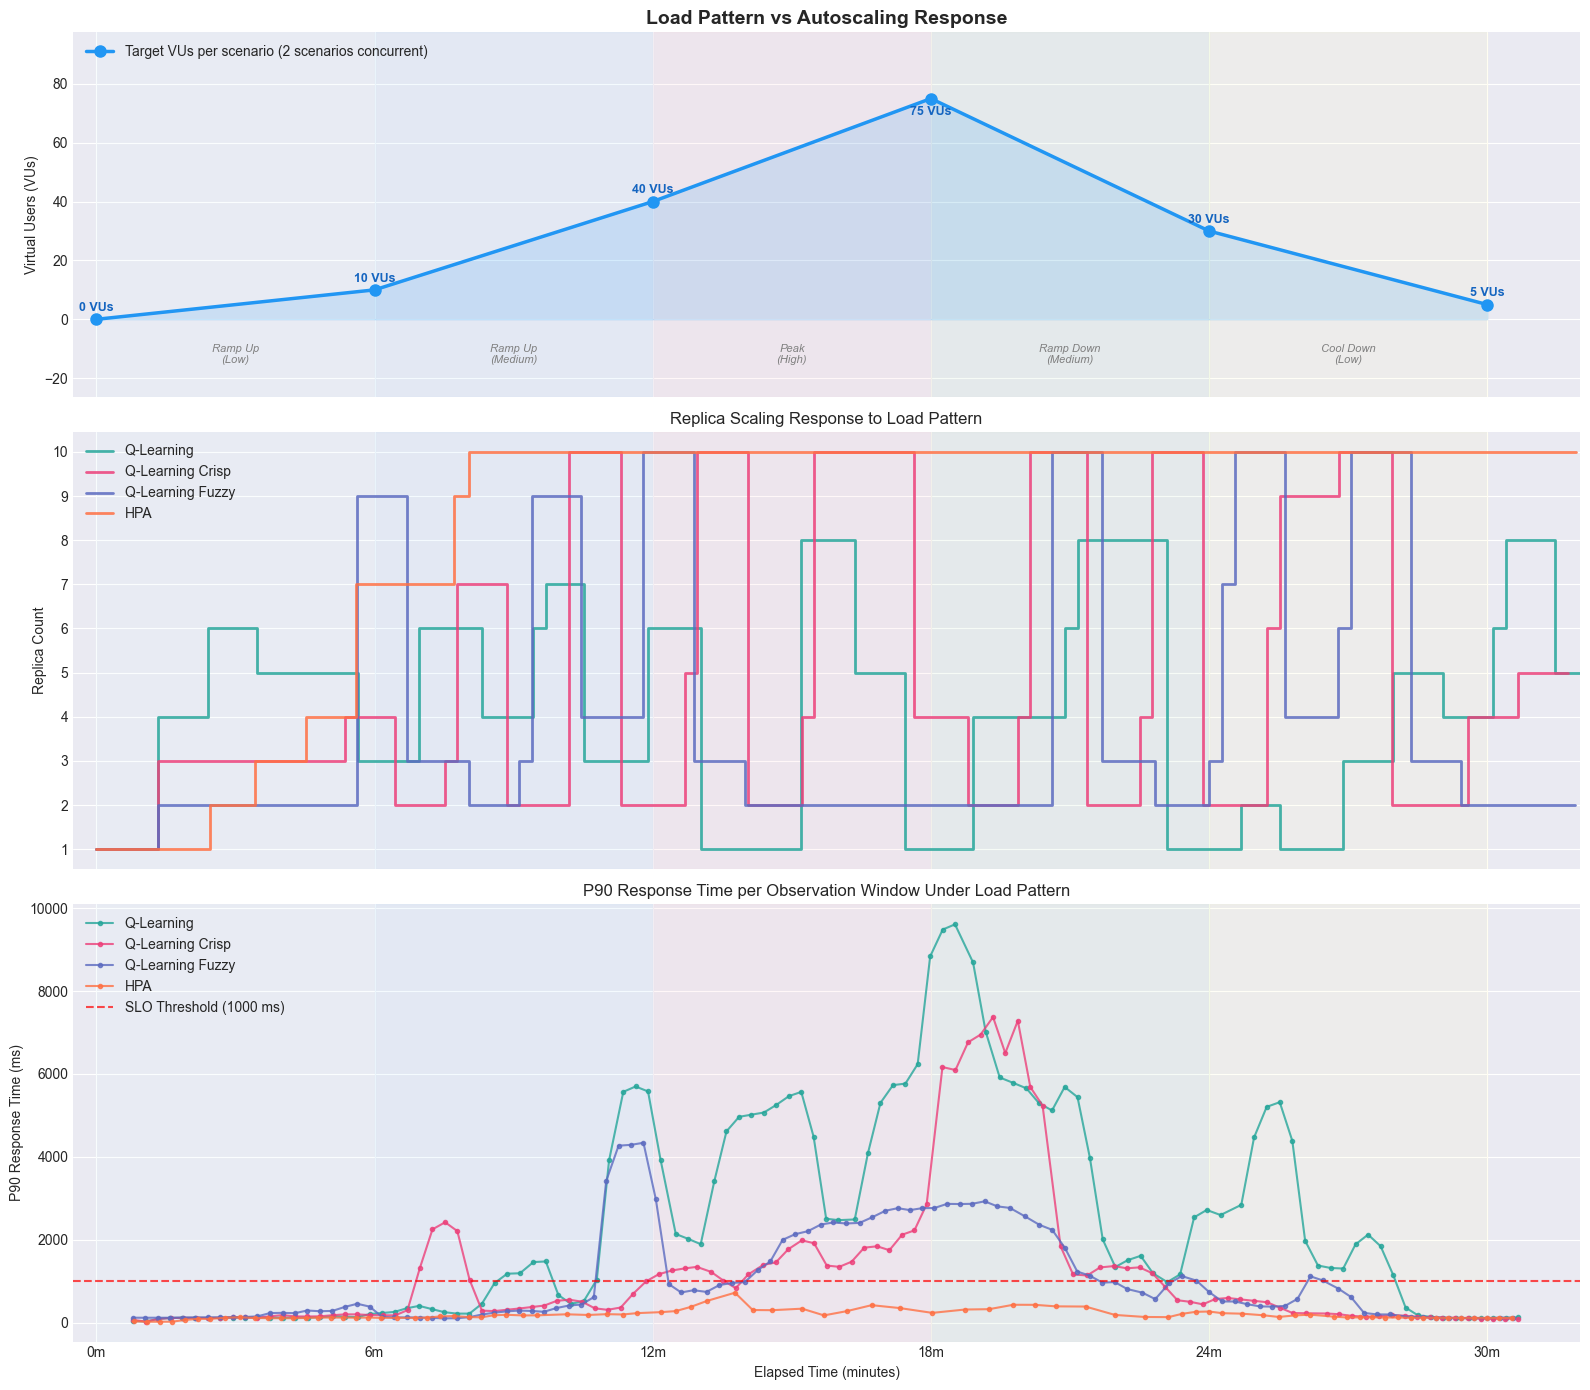


                        LOAD STAGE vs AUTOSCALING RESPONSE SUMMARY                        

  Stage: 0-6m (0->10 VUs)
  Method                  Avg Replica Avg P90 (ms) Max P90 (ms)   Windows > SLO
  ------------------------------------------------------------------------------
  Q-Learning                      4.0        121.9        212.9            0/20
  Q-Learning Crisp                2.7        137.8        203.5            0/20
  Q-Learning Fuzzy                2.4        211.6        458.7            0/20
  HPA                             2.6         95.7        132.8            0/19

  Stage: 6-12m (10->40 VUs)
  Method                  Avg Replica Avg P90 (ms) Max P90 (ms)   Windows > SLO
  ------------------------------------------------------------------------------
  Q-Learning                      4.7       1476.3       5698.1            9/22
  Q-Learning Crisp                4.5        739.8       2423.7            6/22
  Q-Learning Fuzzy                5.0        942.0

In [62]:
# k6_stages / k6_times_min / k6_vus / VU_MAX / stage_colors / stage_labels are
# defined once in the "Pola Beban Pengujian (k6 ramping-vus)" cell near the top.

# Convert elapsed_s to elapsed_min for testing data
for k in METHODS:
    dfs[k]['elapsed_min'] = dfs[k]['elapsed_s'] / 60.0

# --- Combined 3-panel figure ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1.2, 1.2]})

# Apply stage shading to all panels
for ax in axes:
    for i in range(len(k6_stages)):
        ax.axvspan(k6_times_min[i], k6_times_min[i+1], alpha=0.15, color=stage_colors[i])

# ---- Panel 1: Load Pattern (VUs) ----
ax = axes[0]
ax.plot(k6_times_min, k6_vus, marker='o', linewidth=2.5, color='#2196F3',
        markersize=8, zorder=3, label='Target VUs per scenario (2 scenarios concurrent)')
ax.fill_between(k6_times_min, k6_vus, alpha=0.15, color='#2196F3')

# Annotate VU targets
for i, (t_val, v) in enumerate(zip(k6_times_min, k6_vus)):
    offset_y = 6 if v != max(k6_vus) else -12
    ax.annotate(f'{v} VUs', (t_val, v), textcoords='offset points',
                xytext=(0, offset_y), ha='center', fontsize=9, fontweight='bold', color='#1565C0')

# Stage labels at bottom of panel 1
for i in range(len(k6_stages)):
    mid = (k6_times_min[i] + k6_times_min[i+1]) / 2
    ax.text(mid, -0.20 * VU_MAX, stage_labels[i], ha='center', fontsize=8, style='italic', color='gray')

ax.set_ylabel('Virtual Users (VUs)')
ax.set_title('Load Pattern vs Autoscaling Response', fontsize=14, fontweight='bold')
# Derive the limits from the data so the peak and its annotation always fit.
ax.set_ylim(-0.35 * VU_MAX, VU_MAX * 1.30)
ax.legend(loc='upper left')

# ---- Panel 2: Replica Count ----
ax = axes[1]
for key, df, label in datasets:
    ax.step(df['elapsed_min'], df['replica_state'], where='post', linewidth=2,
            label=label, color=COLORS[key], alpha=0.85)

ax.set_ylabel('Replica Count')
ax.set_title('Replica Scaling Response to Load Pattern')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(loc='upper left')

# ---- Panel 3: Response Time ----
ax = axes[2]
SLO_THRESHOLD = 1000

for key, df, label in datasets:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
            marker='o', markersize=3, linewidth=1.5, label=label, color=COLORS[key], alpha=0.8)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (minutes)')
ax.set_ylabel('P90 Response Time (ms)')
ax.set_title('P90 Response Time per Observation Window Under Load Pattern')
ax.legend(loc='upper left')

# Shared x-axis ticks at stage boundaries
for ax in axes:
    ax.set_xticks(k6_times_min)
    ax.set_xticklabels([f'{tt}m' for tt in k6_times_min])
    ax.set_xlim(-0.5, max(k6_times_min) + 2)

plt.tight_layout()
plt.show()

# --- Summary: reaction per stage ---
stage_boundaries = list(zip(k6_times_min[:-1], k6_times_min[1:]))
stage_names = ['0-6m (0->10 VUs)', '6-12m (10->40 VUs)', '12-18m (40->75 VUs)',
               '18-24m (75->30 VUs)', '24-30m (30->5 VUs)']

print(f'\n{"=" * 90}')
print(f'{"LOAD STAGE vs AUTOSCALING RESPONSE SUMMARY":^90}')
print(f'{"=" * 90}')

for stage_name, (t_start, t_end) in zip(stage_names, stage_boundaries):
    print(f'\n  Stage: {stage_name}')
    print(f'  {"Method":<22} {"Avg Replica":>12} {"Avg P90 (ms)":>12} {"Max P90 (ms)":>12} {"Windows > SLO":>15}')
    print(f'  {"-" * 78}')
    for key, df, label in datasets:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        stage_df = df.loc[mask]
        if len(stage_df) == 0:
            print(f'  {label:<22} {"N/A":>12} {"N/A":>12} {"N/A":>12} {"N/A":>15}')
            continue
        avg_rep = stage_df['replica_state'].mean()
        rt_valid = stage_df.loc[stage_df['response_time_ms'].notna() & (stage_df['response_time_ms'] > 0), 'response_time_ms']
        avg_rt = rt_valid.mean() if len(rt_valid) > 0 else 0
        max_rt = rt_valid.max() if len(rt_valid) > 0 else 0
        violations = (rt_valid > SLO_THRESHOLD).sum() if len(rt_valid) > 0 else 0
        total_valid = len(rt_valid)
        viol_str = f'{violations}/{total_valid}' if total_valid > 0 else 'N/A'
        print(f'  {label:<22} {avg_rep:>12.1f} {avg_rt:>12.1f} {max_rt:>12.1f} {viol_str:>15}')

## 6.1.12 Replica Count & Response Time dengan Load Pattern Background

Grafik replica count dan response time untuk keempat metode dengan pola beban k6 (VUs) sebagai background menggunakan dual y-axis.

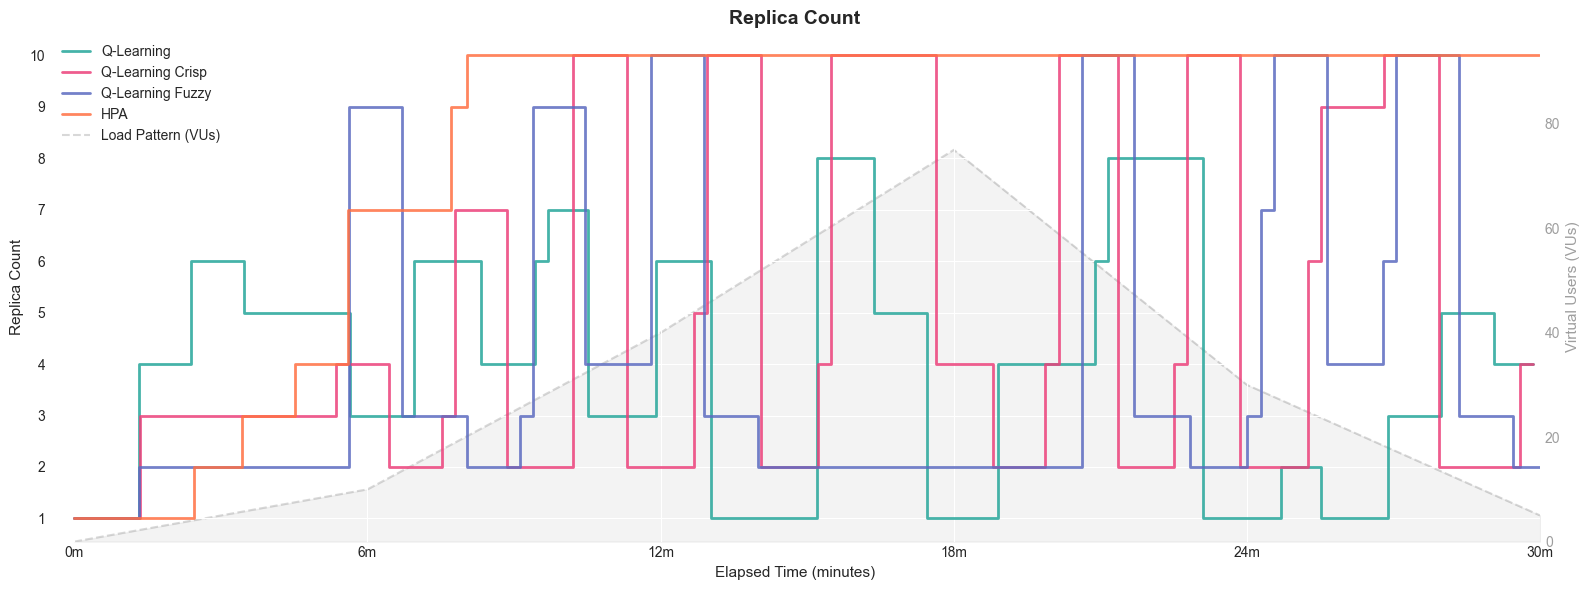

In [63]:
# --- Replica Count with Load Pattern background (twinx) ---
fig, ax1 = plt.subplots(figsize=(16, 6))

# Limit data and stages to first 30 minutes
X_LIMIT_MIN = 30
k6_times_min_30 = [tt for tt in k6_times_min if tt <= X_LIMIT_MIN]
k6_vus_30 = k6_vus[:len(k6_times_min_30)]

# Background: Load pattern (VUs) on secondary y-axis
ax2 = ax1.twinx()
ax2.fill_between(k6_times_min_30, k6_vus_30, alpha=0.12, color='#9E9E9E')
ax2.plot(k6_times_min_30, k6_vus_30, linewidth=1.5, color='#9E9E9E', alpha=0.4,
         linestyle='--', label='Load Pattern (VUs)')
ax2.set_ylabel('Virtual Users (VUs)', color='#9E9E9E', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#9E9E9E', labelsize=10)
ax2.set_ylim(0, max(k6_vus) * 1.30)

# Foreground: Replica count per method
for key, df, label in datasets:
    mask = df['elapsed_min'] <= X_LIMIT_MIN
    ax1.step(df.loc[mask, 'elapsed_min'], df.loc[mask, 'replica_state'], where='post', linewidth=2,
             label=label, color=COLORS[key], alpha=0.85)

ax1.set_xlabel('Elapsed Time (minutes)', fontsize=11)
ax1.set_ylabel('Replica Count', fontsize=11)
ax1.set_title('Replica Count', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Ensure foreground is on top
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.set_xticks(k6_times_min_30)
ax1.set_xticklabels([f'{tt}m' for tt in k6_times_min_30])
ax1.set_xlim(-0.5, X_LIMIT_MIN)

plt.tight_layout()
plt.show()

### Alternatif Visualisasi Proses Scaling Replica

Grafik `Replica Count` di atas menumpuk empat fungsi tangga pada satu sumbu, sehingga
garis saling menutupi dan pola tiap metode sulit dibaca. Dua alternatif yang lebih
terbaca disajikan di bawah ini:

1. **Small multiples** - satu panel per metode dengan skala sumbu yang sama, pola beban
   k6 diletakkan sebagai latar. Cocok untuk membaca perilaku tiap metode secara terpisah
   sekaligus membandingkannya secara vertikal.
2. **Heatmap** - jumlah replica dinyatakan sebagai warna, satu baris per metode. Cocok
   untuk melihat *kapan* tiap metode menaikkan atau menurunkan replica dalam satu tampilan
   yang padat.

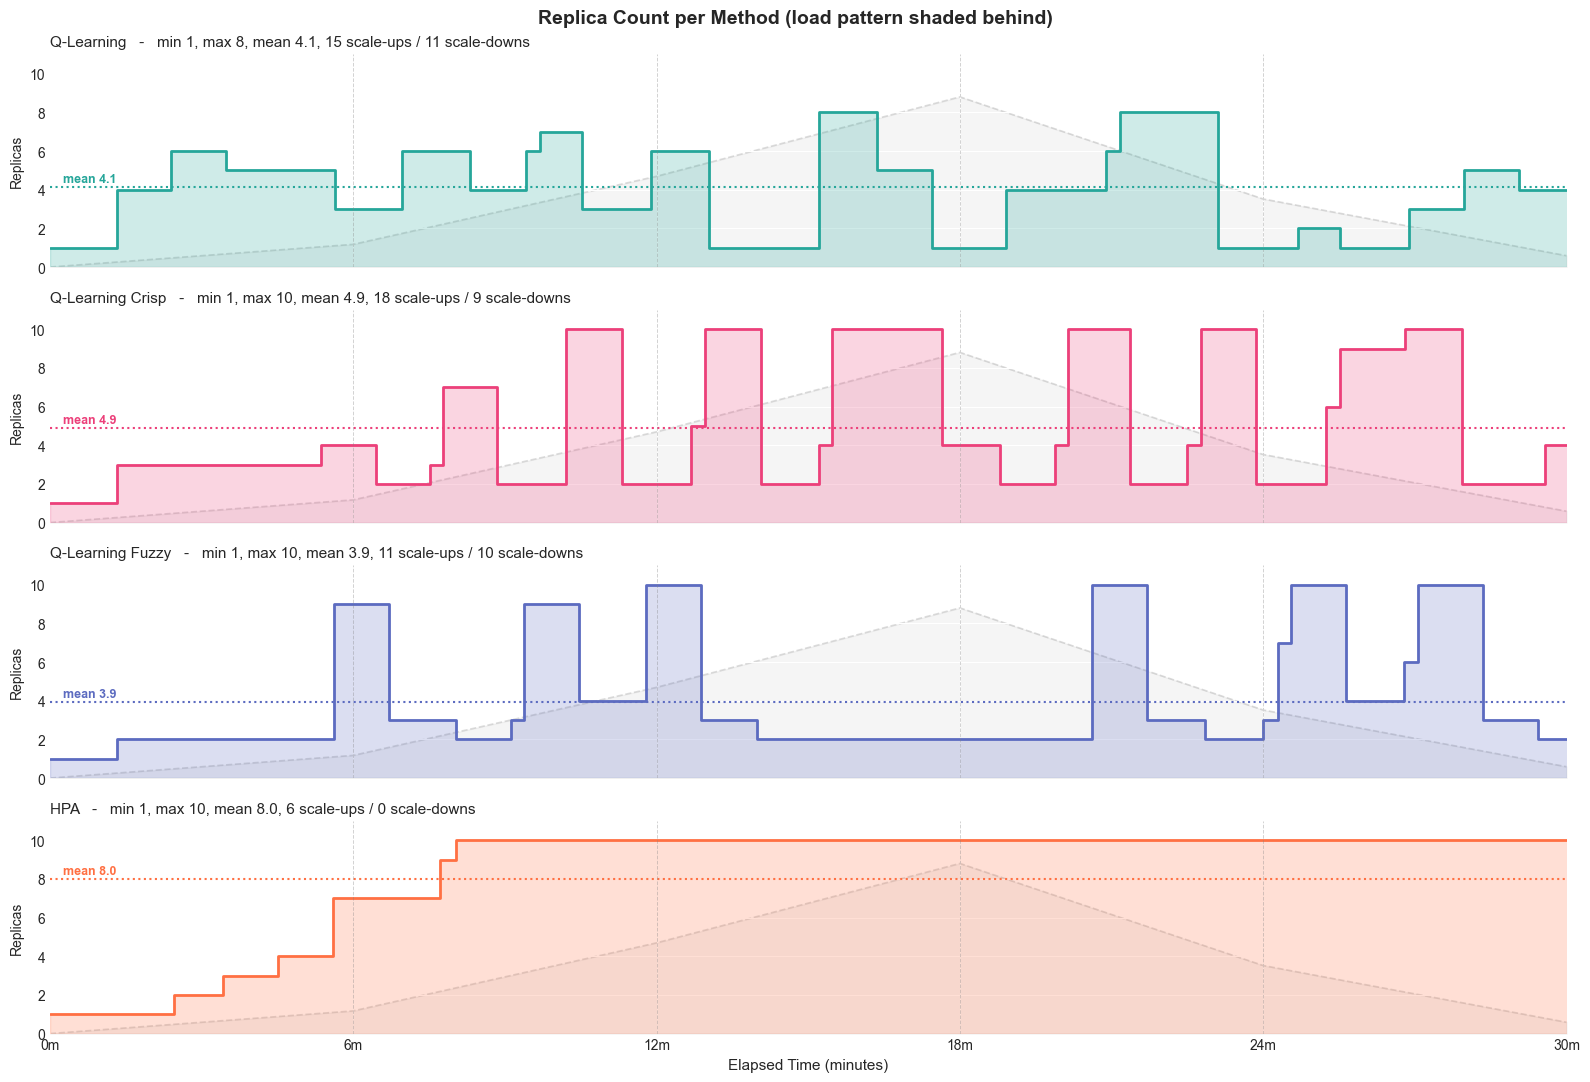

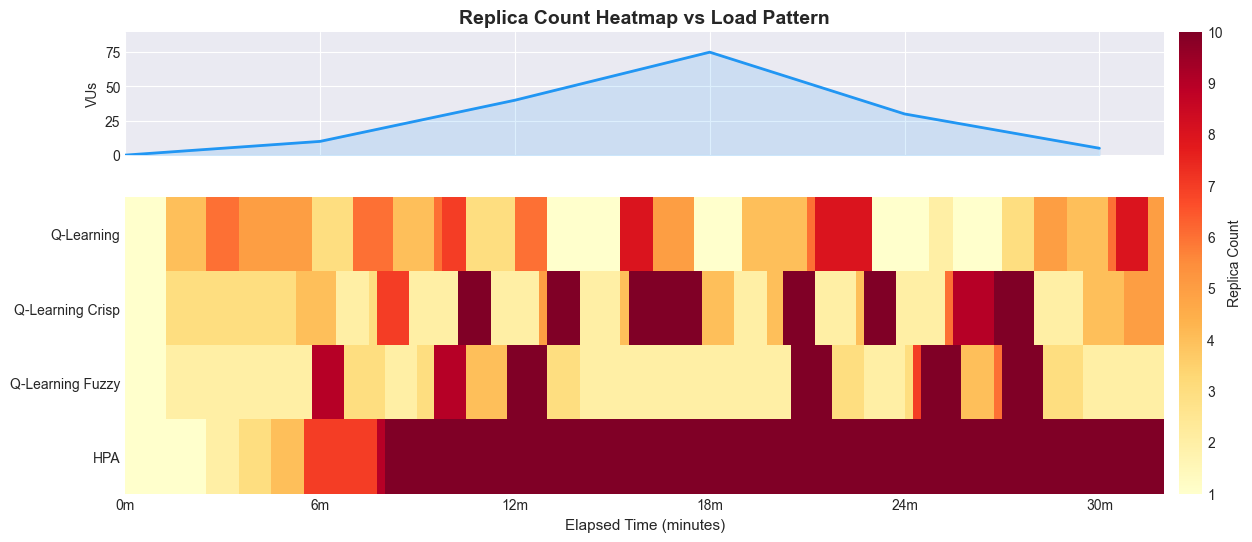

                                   SCALING ACTIVITY                                   
Method                  Scale-ups  Scale-downs  Mean rep.  Replica-min     vs HPA
--------------------------------------------------------------------------------------
Q-Learning                     15           11       4.14        131.5       49%
Q-Learning Crisp               18            9       4.89        156.8       58%
Q-Learning Fuzzy               11           10       3.92        126.4       47%
HPA                             6            0       8.01        268.5      100%
--------------------------------------------------------------------------------------
Replica-min = integral of the replica count over time (proxy for resource cost);
"vs HPA" expresses it relative to the HPA baseline.


In [64]:
# --- Two readable alternatives to the overlaid replica step chart ---

REP_MAX = int(max(df['replica_state'].max() for _, df, _ in datasets))

# ============================ 1. Small multiples ============================
fig, axes = plt.subplots(len(METHODS), 1, figsize=(16, 11), sharex=True, sharey=True)

for ax, (key, df, label) in zip(axes, datasets):
    # Load pattern as a faint background on a hidden twin axis
    axv = ax.twinx()
    axv.fill_between(k6_times_min, k6_vus, color='#9E9E9E', alpha=0.10)
    axv.plot(k6_times_min, k6_vus, color='#9E9E9E', alpha=0.35, linestyle='--', linewidth=1.2)
    axv.set_ylim(0, VU_MAX * 1.25)
    axv.set_yticks([])

    ax.step(df['elapsed_min'], df['replica_state'], where='post',
            color=COLORS[key], linewidth=2)
    ax.fill_between(df['elapsed_min'], df['replica_state'], step='post',
                    color=COLORS[key], alpha=0.22)

    mean_rep = df['replica_state'].mean()
    ax.axhline(mean_rep, color=COLORS[key], linestyle=':', linewidth=1.5)
    ax.text(0.25, mean_rep + 0.25, f'mean {mean_rep:.1f}', fontsize=9,
            color=COLORS[key], fontweight='bold')

    # Stage boundaries
    for b in k6_times_min[1:-1]:
        ax.axvline(b, color='gray', linestyle='--', linewidth=0.7, alpha=0.35)

    diff = df['replica_state'].diff()
    ax.set_title(f'{label}   -   min {int(df["replica_state"].min())}, '
                 f'max {int(df["replica_state"].max())}, mean {mean_rep:.1f}, '
                 f'{int((diff > 0).sum())} scale-ups / {int((diff < 0).sum())} scale-downs',
                 fontsize=11, loc='left')
    ax.set_ylabel('Replicas')
    ax.set_ylim(0, REP_MAX + 1)
    ax.set_yticks(range(0, REP_MAX + 1, 2))

    # Keep the replica line in front of the load background
    ax.set_zorder(axv.get_zorder() + 1)
    ax.patch.set_visible(False)

axes[-1].set_xlabel('Elapsed Time (minutes)', fontsize=11)
axes[-1].set_xticks(k6_times_min)
axes[-1].set_xticklabels([f'{t}m' for t in k6_times_min])
axes[-1].set_xlim(0, max(k6_times_min))
fig.suptitle('Replica Count per Method (load pattern shaded behind)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================ 2. Heatmap ================================
# Resample every run onto one common 15 s grid. 'ffill' keeps step semantics:
# a replica count holds until the next observation.
BIN_S = 15.0
edges_s = np.arange(0, HORIZON_S + BIN_S, BIN_S)
centers_s = (edges_s[:-1] + edges_s[1:]) / 2

mat = []
for key in METHODS:
    d = dfs[key]
    s = pd.Series(d['replica_state'].values, index=d['elapsed_s'].values)
    s = s[~s.index.duplicated(keep='first')].sort_index()
    mat.append(s.reindex(centers_s, method='ffill').bfill().values)
mat = np.asarray(mat, dtype=float)

fig, (axl, axh) = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                               gridspec_kw={'height_ratios': [1, 2.4]})

axl.plot(k6_times_min, k6_vus, color='#2196F3', linewidth=2)
axl.fill_between(k6_times_min, k6_vus, color='#2196F3', alpha=0.15)
axl.set_ylabel('VUs')
axl.set_ylim(0, VU_MAX * 1.2)
axl.set_title('Replica Count Heatmap vs Load Pattern', fontsize=14, fontweight='bold')

mesh = axh.pcolormesh(edges_s / 60.0, np.arange(len(METHODS) + 1), mat,
                      cmap='YlOrRd', vmin=1, vmax=REP_MAX, shading='flat')
axh.set_yticks(np.arange(len(METHODS)) + 0.5)
axh.set_yticklabels([LABELS[k] for k in METHODS])
axh.invert_yaxis()
axh.set_xlabel('Elapsed Time (minutes)', fontsize=11)
axh.set_xticks(k6_times_min)
axh.set_xticklabels([f'{t}m' for t in k6_times_min])
axh.set_xlim(0, edges_s[-1] / 60.0)

cbar = fig.colorbar(mesh, ax=[axl, axh], pad=0.012)
cbar.set_label('Replica Count')
plt.show()

# ============================== Scaling summary =============================
print(f'{"SCALING ACTIVITY":^86}')
print('=' * 86)
print(f'{"Method":<22} {"Scale-ups":>10} {"Scale-downs":>12} {"Mean rep.":>10} '
      f'{"Replica-min":>12} {"vs HPA":>10}')
print('-' * 86)

rep_minutes = {}
for key, df, label in datasets:
    dt = df['elapsed_min'].diff().fillna(0.0)
    held = df['replica_state'].shift(1).fillna(df['replica_state'].iloc[0])
    rep_minutes[key] = float((held * dt).sum())

for key, df, label in datasets:
    diff = df['replica_state'].diff()
    ratio = rep_minutes[key] / rep_minutes['hpa'] if rep_minutes.get('hpa') else float('nan')
    print(f'{label:<22} {int((diff > 0).sum()):>10} {int((diff < 0).sum()):>12} '
          f'{df["replica_state"].mean():>10.2f} {rep_minutes[key]:>12.1f} {ratio:>9.0%}')
print('-' * 86)
print('Replica-min = integral of the replica count over time (proxy for resource cost);')
print('"vs HPA" expresses it relative to the HPA baseline.')


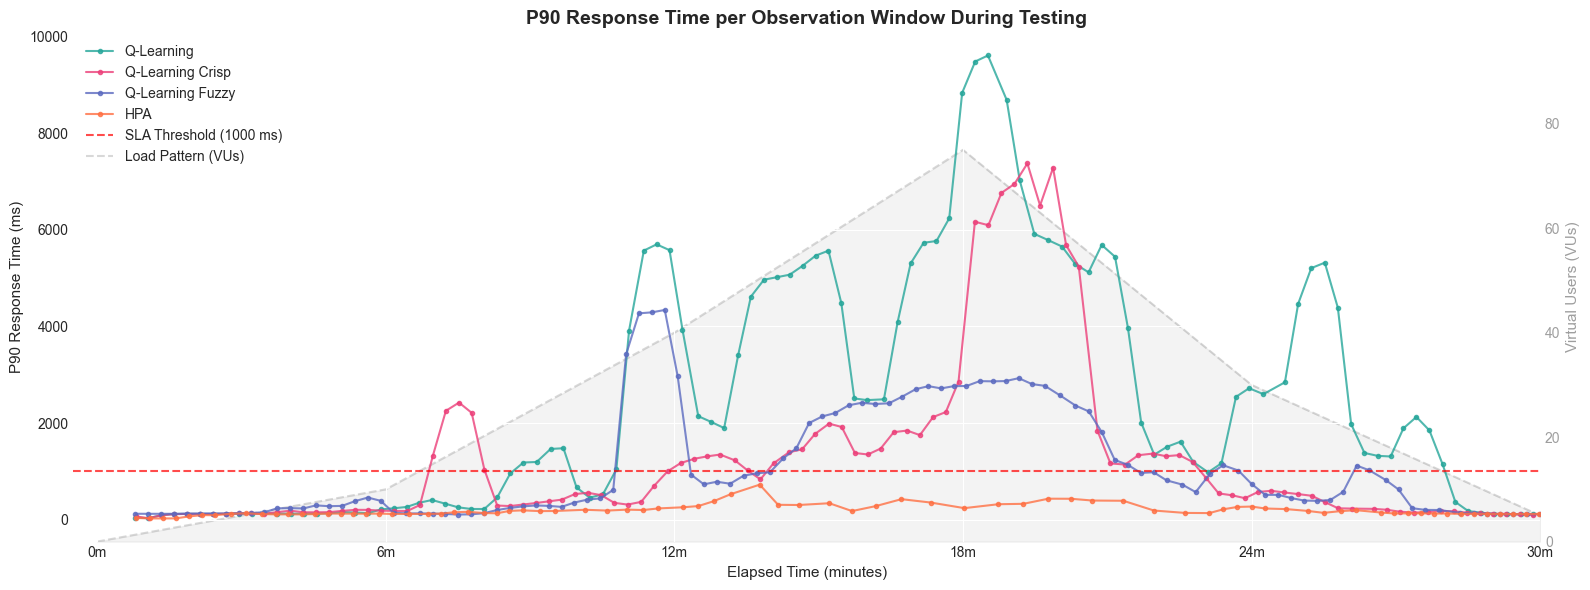

In [65]:
# --- Response Time with Load Pattern background (twinx) ---
fig, ax1 = plt.subplots(figsize=(16, 6))

# Limit data and stages to first 30 minutes
X_LIMIT_MIN = 30
k6_times_min_30 = [tt for tt in k6_times_min if tt <= X_LIMIT_MIN]
k6_vus_30 = k6_vus[:len(k6_times_min_30)]

# Background: Load pattern (VUs) on secondary y-axis
ax2 = ax1.twinx()
ax2.fill_between(k6_times_min_30, k6_vus_30, alpha=0.12, color='#9E9E9E')
ax2.plot(k6_times_min_30, k6_vus_30, linewidth=1.5, color='#9E9E9E', alpha=0.4,
         linestyle='--', label='Load Pattern (VUs)')
ax2.set_ylabel('Virtual Users (VUs)', color='#9E9E9E', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#9E9E9E', labelsize=10)
ax2.set_ylim(0, max(k6_vus) * 1.30)

# Foreground: Response time per method
SLO_THRESHOLD = 1000
for key, df, label in datasets:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0) & (df['elapsed_min'] <= X_LIMIT_MIN)
    ax1.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
             marker='o', markersize=3, linewidth=1.5, label=label, color=COLORS[key], alpha=0.8)

ax1.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'SLA Threshold ({SLO_THRESHOLD} ms)')

ax1.set_xlabel('Elapsed Time (minutes)', fontsize=11)
ax1.set_ylabel('P90 Response Time (ms)', fontsize=11)
ax1.set_title('P90 Response Time per Observation Window During Testing', fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Ensure foreground is on top
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.set_xticks(k6_times_min_30)
ax1.set_xticklabels([f'{tt}m' for tt in k6_times_min_30])
ax1.set_xlim(-0.5, X_LIMIT_MIN)

plt.tight_layout()
plt.show()

## 6.1.13 Analisis Pelanggaran SLA per Load Stage (Response Time > 1000ms)

Jumlah dan persentase pelanggaran SLA per load stage selama pengujian untuk keempat metode autoscaling.

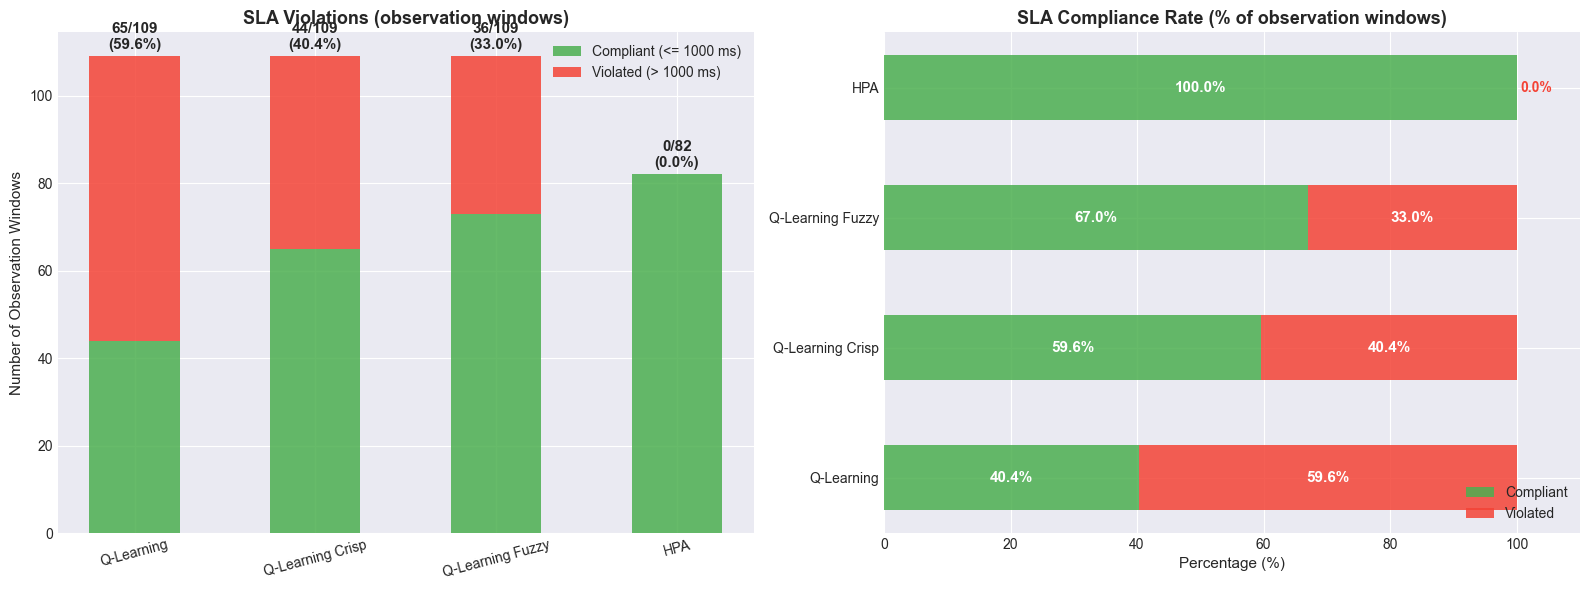

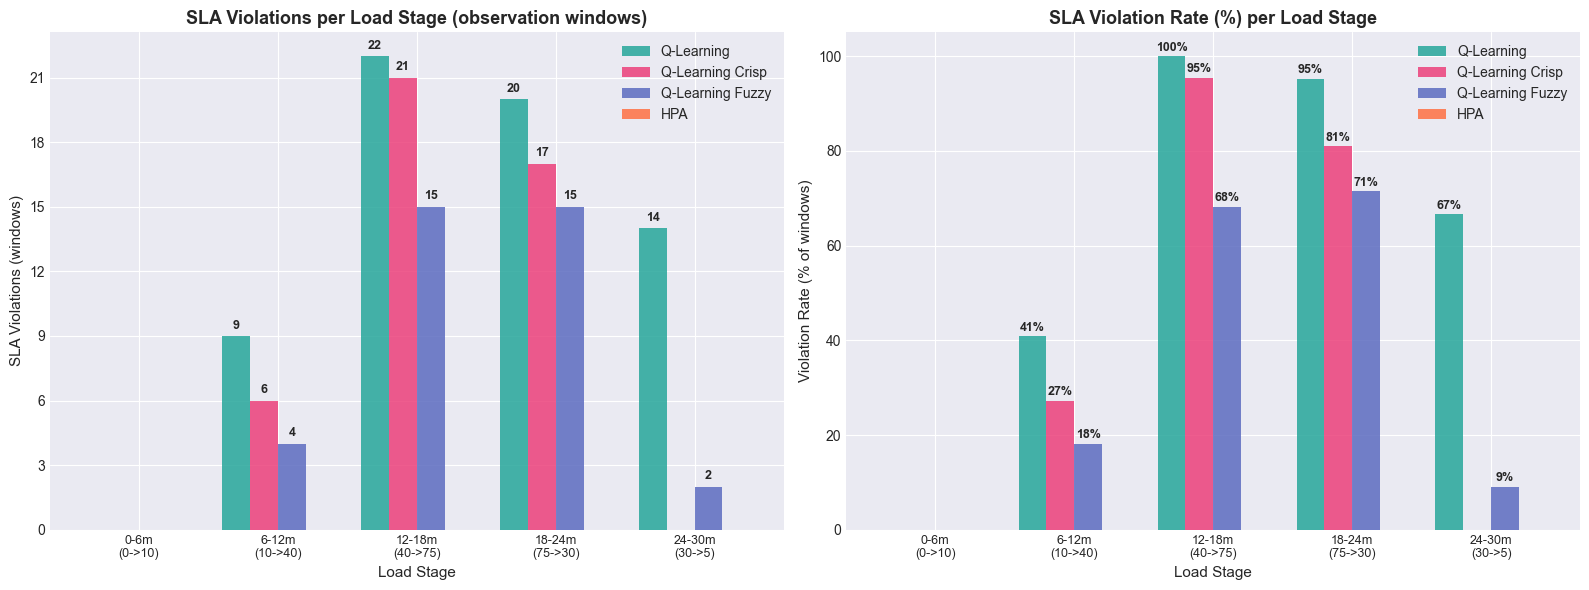


                   SLA VIOLATION SUMMARY (Threshold: 1000 ms)                   

Method                  Windows  Compliant   Violated  Violation %
-----------------------------------------------------------------
Q-Learning                  109         44         65        59.6%
Q-Learning Crisp            109         65         44        40.4%
Q-Learning Fuzzy            109         73         36        33.0%
HPA                          82         82          0         0.0%

                              SLA Violations per Load Stage                               
------------------------------------------------------------------------------------------
Stage                          Q-Learning   Q-Learning Crisp   Q-Learning Fuzzy                HPA
------------------------------------------------------------------------------------------
0-6m (0->10 VUs)         0/20 (   0%)   0/20 (   0%)   0/20 (   0%)   0/19 (   0%)
6-12m (10->40 VUs)       9/22 (  41%)   6/22 (  27%)   4/22 

In [66]:
SLA_THRESHOLD = 1000  # ms (from .env MAX_RESPONSE_TIME)

# As in 6.1.7: the unit of counting is the OBSERVATION WINDOW (one CSV row = the mean
# of the per-endpoint P90s over one ~15 s window), not the individual request.

datasets_sla = datasets

# --- 1) Overall SLA comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sla_stats = {}
for key, df, label in datasets_sla:
    valid = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    total = valid.sum()
    violated = (df.loc[valid, 'response_time_ms'] > SLA_THRESHOLD).sum()
    compliant = total - violated
    pct_violated = violated / total * 100 if total > 0 else 0
    sla_stats[label] = {'total': total, 'violated': violated, 'compliant': compliant,
                         'pct_violated': pct_violated, 'pct_compliant': 100 - pct_violated}

# Left: Stacked bar chart (count)
ax = axes[0]
methods = list(sla_stats.keys())
compliant_vals = [sla_stats[m]['compliant'] for m in methods]
violated_vals = [sla_stats[m]['violated'] for m in methods]
total_vals = [sla_stats[m]['total'] for m in methods]

x = np.arange(len(methods))
width = 0.5
ax.bar(x, compliant_vals, width, label=f'Compliant (<= {SLA_THRESHOLD} ms)', color='#4CAF50', alpha=0.85)
ax.bar(x, violated_vals, width, bottom=compliant_vals, label=f'Violated (> {SLA_THRESHOLD} ms)', color='#F44336', alpha=0.85)

for i in range(len(methods)):
    v = violated_vals[i]
    t = total_vals[i]
    pct = v / t * 100 if t > 0 else 0
    ax.text(i, t + 1, f'{v}/{t}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Observation Windows', fontsize=11)
ax.set_title('SLA Violations (observation windows)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10, rotation=15)
ax.legend(fontsize=10)

# Right: Horizontal percentage bar
ax = axes[1]
pct_c = [sla_stats[m]['pct_compliant'] for m in methods]
pct_v = [sla_stats[m]['pct_violated'] for m in methods]

ax.barh(x, pct_c, height=0.5, label='Compliant', color='#4CAF50', alpha=0.85)
ax.barh(x, pct_v, height=0.5, left=pct_c, label='Violated', color='#F44336', alpha=0.85)

for i in range(len(methods)):
    if pct_c[i] > 15:
        ax.text(pct_c[i] / 2, i, f'{pct_c[i]:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if pct_v[i] > 5:
        ax.text(pct_c[i] + pct_v[i] / 2, i, f'{pct_v[i]:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    else:
        ax.text(100.5, i, f'{pct_v[i]:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold', color='#F44336')

ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_title('SLA Compliance Rate (% of observation windows)', fontsize=13, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(methods, fontsize=10)
ax.set_xlim(0, 110)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

# --- 2) SLA violations per load stage ---
stage_boundaries_min = list(zip(k6_times_min[:-1], k6_times_min[1:]))
stage_names_short = ['0-6m\n(0->10)', '6-12m\n(10->40)', '12-18m\n(40->75)',
                     '18-24m\n(75->30)', '24-30m\n(30->5)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_stage = np.arange(len(stage_names_short))
n = len(datasets_sla)
width = 0.8 / n

# Left: violation count per stage
ax = axes[0]
for i, (key, df, label) in enumerate(datasets_sla):
    viol_per_stage = []
    for t_start, t_end in stage_boundaries_min:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        viol = (df.loc[mask].loc[valid, 'response_time_ms'] > SLA_THRESHOLD).sum()
        viol_per_stage.append(viol)
    bars = ax.bar(x_stage + (i - (n - 1) / 2) * width, viol_per_stage, width, label=label, color=COLORS[key], alpha=0.85)
    for bar, val in zip(bars, viol_per_stage):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                    str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Load Stage', fontsize=11)
ax.set_ylabel('SLA Violations (windows)', fontsize=11)
ax.set_title('SLA Violations per Load Stage (observation windows)', fontsize=13, fontweight='bold')
ax.set_xticks(x_stage)
ax.set_xticklabels(stage_names_short, fontsize=9)
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Right: violation percentage per stage
ax = axes[1]
for i, (key, df, label) in enumerate(datasets_sla):
    pct_per_stage = []
    for t_start, t_end in stage_boundaries_min:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid_mask = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        total = valid_mask.sum()
        viol = (df.loc[mask].loc[valid_mask, 'response_time_ms'] > SLA_THRESHOLD).sum()
        pct = viol / total * 100 if total > 0 else 0
        pct_per_stage.append(pct)
    bars = ax.bar(x_stage + (i - (n - 1) / 2) * width, pct_per_stage, width, label=label, color=COLORS[key], alpha=0.85)
    for bar, val in zip(bars, pct_per_stage):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Load Stage', fontsize=11)
ax.set_ylabel('Violation Rate (% of windows)', fontsize=11)
ax.set_title('SLA Violation Rate (%) per Load Stage', fontsize=13, fontweight='bold')
ax.set_xticks(x_stage)
ax.set_xticklabels(stage_names_short, fontsize=9)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# --- 3) Summary Table ---
print(f'\n{"=" * 80}')
print(f'{"SLA VIOLATION SUMMARY (Threshold: " + str(SLA_THRESHOLD) + " ms)":^80}')
print(f'{"=" * 80}')
print(f'\n{"Method":<22} {"Windows":>8} {"Compliant":>10} {"Violated":>10} {"Violation %":>12}')
print(f'{"-" * 65}')
for label in methods:
    s = sla_stats[label]
    print(f'{label:<22} {s["total"]:>8} {s["compliant"]:>10} {s["violated"]:>10} {s["pct_violated"]:>11.1f}%')

print(f'\n{"SLA Violations per Load Stage":^90}')
print(f'{"-" * 90}')
stage_names_full = ['0-6m (0->10 VUs)', '6-12m (10->40 VUs)', '12-18m (40->75 VUs)',
                    '18-24m (75->30 VUs)', '24-30m (30->5 VUs)']
header = f'{"Stage":<22}'
for key, df, label in datasets_sla:
    header += f' {label:>18}'
print(header)
print(f'{"-" * 90}')
for stage_name, (t_start, t_end) in zip(stage_names_full, stage_boundaries_min):
    row = f'{stage_name:<22}'
    for key, df, label in datasets_sla:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid_mask = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        total = valid_mask.sum()
        viol = (df.loc[mask].loc[valid_mask, 'response_time_ms'] > SLA_THRESHOLD).sum()
        pct = viol / total * 100 if total > 0 else 0
        row += f' {viol:>3}/{total:<3}({pct:>4.0f}%)'
    print(row)

## 6.1.14 Perbandingan P90: k6 (client-side) vs Prometheus (server-side)

Dua sumber pengukuran latensi dibandingkan berdampingan.

- **k6** (`http_req_duration`) - diukur di sisi klien, mencakup jaringan, ingress, dan
  antrian sebelum request masuk ke handler. P90 dihitung atas **seluruh request** dalam
  satu run (request-weighted), gabungan kedua endpoint. Inilah angka yang diuji terhadap
  threshold `p(90)<1000`. Sumber: ringkasan akhir k6 pada `data/testing/60-episodes/*/image.png`.
- **Prometheus** (`response_time_ms` pada CSV) - diukur di sisi server dari histogram
  aplikasi, yaitu **rata-rata P90 per endpoint** (`/cpu`, `/memory`) untuk setiap jendela
  observasi (~15 detik). Inilah angka yang dilihat agent sebagai state dan reward.

Keduanya mengukur hal yang berbeda, sehingga nilainya tidak dapat dipertukarkan maupun
diplot pada sumbu yang sama.

In [67]:
# k6 end-of-test summaries, transcribed from data/testing/60-episodes/<run>/image.png.
# http_req_duration, client-side, all requests of both scenarios combined, per run.
# Durations in ms.
K6_SUMMARY = {
    # run 1 (folder '1', finished 2026-08-07 ~15:02)
    ('ql', 1):     {'avg': 1100.0, 'med': 266.41, 'p90': 2680.0, 'p95': 4830.0, 'max': 60000.0, 'reqs': 53862, 'failed_pct': 0.72},
    ('qcrisp', 1): {'avg': 696.58, 'med': 228.42, 'p90': 1410.0, 'p95': 2310.0, 'max': 52050.0, 'reqs': 66737, 'failed_pct': 0.73},
    ('qfuzzy', 1): {'avg': 662.93, 'med': 284.48, 'p90': 1730.0, 'p95': 2570.0, 'max': 13630.0, 'reqs': 68018, 'failed_pct': 0.34},
    # run 2 (folder '2', finished ~15:37)
    ('ql', 2):     {'avg': 769.89, 'med': 176.84, 'p90': 1730.0, 'p95': 3110.0, 'max': 42840.0, 'reqs': 63951, 'failed_pct': 0.29},
    ('qcrisp', 2): {'avg': 547.29, 'med': 186.81, 'p90': 1400.0, 'p95': 2360.0, 'max': 12230.0, 'reqs': 73100, 'failed_pct': 0.46},
    ('qfuzzy', 2): {'avg': 819.55, 'med': 145.40, 'p90': 1580.0, 'p95': 3800.0, 'max': 44910.0, 'reqs': 62289, 'failed_pct': 0.43},
    # run 3 (folder '3', finished ~16:11)
    ('ql', 3):     {'avg': 525.07, 'med': 137.12, 'p90': 1110.0, 'p95': 2590.0, 'max': 25240.0, 'reqs': 74181, 'failed_pct': 0.35},
    ('qcrisp', 3): {'avg': 517.23, 'med': 162.42, 'p90': 1350.0, 'p95': 2390.0, 'max': 12410.0, 'reqs': 74543, 'failed_pct': 0.72},
    ('qfuzzy', 3): {'avg': 808.23, 'med': 127.02, 'p90': 1500.0, 'p95': 3980.0, 'max': 55470.0, 'reqs': 62678, 'failed_pct': 0.32},
    # HPA (folder 'hpa', finished ~16:52) - three k6 instances ran concurrently,
    # one per HPA-managed deployment, matching the three metrics_*.csv files.
    ('hpa', 1):    {'avg': 1200.0, 'med': 933.89, 'p90': 2690.0, 'p95': 3320.0, 'max': 9550.0, 'reqs': 51187, 'failed_pct': 0.00},
    ('hpa', 2):    {'avg': 1200.0, 'med': 920.65, 'p90': 2690.0, 'p95': 3320.0, 'max': 9460.0, 'reqs': 51293, 'failed_pct': 0.00},
    ('hpa', 3):    {'avg': 1190.0, 'med': 917.80, 'p90': 2680.0, 'p95': 3320.0, 'max': 9550.0, 'reqs': 51421, 'failed_pct': 0.00},
}

# All three repetitions of the server-side CSVs, so both columns cover the same runs.
CSV_RUNS = {
    'ql': [f'{DATA_DIR}/1/test_qlearning_20260807_143047.csv',
           f'{DATA_DIR}/2/test_qlearning_20260807_150648.csv',
           f'{DATA_DIR}/3/test_qlearning_20260807_154032.csv'],
    'qcrisp': [f'{DATA_DIR}/1/test_qlearningcrisp_20260807_142854.csv',
               f'{DATA_DIR}/2/test_qlearningcrisp_20260807_150612.csv',
               f'{DATA_DIR}/3/test_qlearningcrisp_20260807_154007.csv'],
    'qfuzzy': [f'{DATA_DIR}/1/test_qlearningfuzzy_20260807_142708.csv',
               f'{DATA_DIR}/2/test_qlearningfuzzy_20260807_150535.csv',
               f'{DATA_DIR}/3/test_qlearningfuzzy_20260807_153940.csv'],
    'hpa': [f'{DATA_DIR}/hpa/metrics_20260807_162124.csv',
            f'{DATA_DIR}/hpa/metrics_20260807_162141.csv',
            f'{DATA_DIR}/hpa/metrics_20260807_162155.csv'],
}


def _window_p90_stats(path):
    """Server-side stats for one run: the per-window P90 series from the CSV."""
    s = pd.read_csv(path)['response_time_ms']
    s = s[s.notna() & (s > 0)]          # drop idle windows (NaN == no traffic)
    return {
        'mean': s.mean(),
        'median': s.median(),
        'viol_pct': (s > SLO_THRESHOLD).mean() * 100,
        'windows': len(s),
    }


rows = []
for key in METHODS:
    k6 = [K6_SUMMARY[(key, r)] for r in (1, 2, 3)]
    csv = [_window_p90_stats(p) for p in CSV_RUNS[key]]
    rows.append({
        'Method': LABELS[key],
        'k6 P90 (ms)': np.mean([d['p90'] for d in k6]),
        'k6 P90 sd': np.std([d['p90'] for d in k6], ddof=1),
        'k6 P95 (ms)': np.mean([d['p95'] for d in k6]),
        'k6 Median (ms)': np.mean([d['med'] for d in k6]),
        'k6 Failed %': np.mean([d['failed_pct'] for d in k6]),
        'Prom mean P90 (ms)': np.mean([d['mean'] for d in csv]),
        'Prom median P90 (ms)': np.mean([d['median'] for d in csv]),
        'Prom windows > SLO %': np.mean([d['viol_pct'] for d in csv]),
    })

summary = pd.DataFrame(rows).set_index('Method')

print(f'{"P90 COMPARISON - k6 (client-side) vs PROMETHEUS (server-side)":^104}')
print(f'{"mean of 3 runs; SLO threshold = " + str(SLO_THRESHOLD) + " ms":^104}')
print('=' * 104)
print(f'{"Method":<20} {"k6 P90":>12} {"k6 P95":>10} {"k6 Median":>11} {"k6 Fail%":>9} '
      f'{"Prom mean":>11} {"Prom med":>10} {"Prom >SLO":>10}')
print('-' * 104)
for m, r in summary.iterrows():
    print(f'{m:<20} {r["k6 P90 (ms)"]:>8.0f} ms{"":>1} {r["k6 P95 (ms)"]:>7.0f} ms '
          f'{r["k6 Median (ms)"]:>8.0f} ms {r["k6 Failed %"]:>8.2f}% '
          f'{r["Prom mean P90 (ms)"]:>8.0f} ms {r["Prom median P90 (ms)"]:>7.0f} ms '
          f'{r["Prom windows > SLO %"]:>9.1f}%')
print('-' * 104)

# Per-run k6 P90, to show the spread the averages hide
print(f'\n{"k6 P90 per run (ms)":^60}')
print('-' * 60)
print(f'{"Method":<20} {"Run 1":>10} {"Run 2":>10} {"Run 3":>10} {"SLO":>7}')
print('-' * 60)
for key in METHODS:
    p90s = [K6_SUMMARY[(key, r)]['p90'] for r in (1, 2, 3)]
    verdict = 'PASS' if all(p < SLO_THRESHOLD for p in p90s) else 'FAIL'
    print(f'{LABELS[key]:<20} {p90s[0]:>10.0f} {p90s[1]:>10.0f} {p90s[2]:>10.0f} {verdict:>7}')
print('-' * 60)
print(f'Every method fails the k6 threshold p(90)<{SLO_THRESHOLD}ms; the HPA run reports it')
print(f'explicitly as: [x] \'p(90)<1000\' p(90)=2.69s')

summary.round(1)


                     P90 COMPARISON - k6 (client-side) vs PROMETHEUS (server-side)                      
                                mean of 3 runs; SLO threshold = 1000 ms                                 
Method                     k6 P90     k6 P95   k6 Median  k6 Fail%   Prom mean   Prom med  Prom >SLO
--------------------------------------------------------------------------------------------------------
Q-Learning               1840 ms     3510 ms      193 ms     0.45%     1800 ms    1039 ms      51.6%
Q-Learning Crisp         1387 ms     2353 ms      193 ms     0.64%      962 ms     411 ms      38.3%
Q-Learning Fuzzy         1603 ms     3450 ms      186 ms     0.36%     1744 ms     889 ms      44.8%
HPA                      2687 ms     3320 ms      924 ms     0.00%      181 ms     140 ms       0.0%
--------------------------------------------------------------------------------------------------------

                    k6 P90 per run (ms)                     
-------------

,k6 P90 (ms),k6 P90 sd,k6 P95 (ms),k6 Median (ms),k6 Failed %,Prom mean P90 (ms),Prom median P90 (ms),Prom windows > SLO %
Method,,,,,,,,
Q-Learning,1840.0,790.8,3510.0,193.5,0.5,1800.0,1039.0,51.6
Q-Learning Crisp,1386.7,32.1,2353.3,192.5,0.6,962.3,410.8,38.3
Q-Learning Fuzzy,1603.3,116.8,3450.0,185.6,0.4,1744.0,889.2,44.8
HPA,2686.7,5.8,3320.0,924.1,0.0,181.2,140.4,0.0
